# Análisis Exploratorio de Datos (EDA)

### Carga de datos

In [1]:
import pandas as pd

df = pd.read_csv('../data/listingV5.csv')

## Dashboards EDA - SmartHost Analytics

### Dashboards 0 y 1

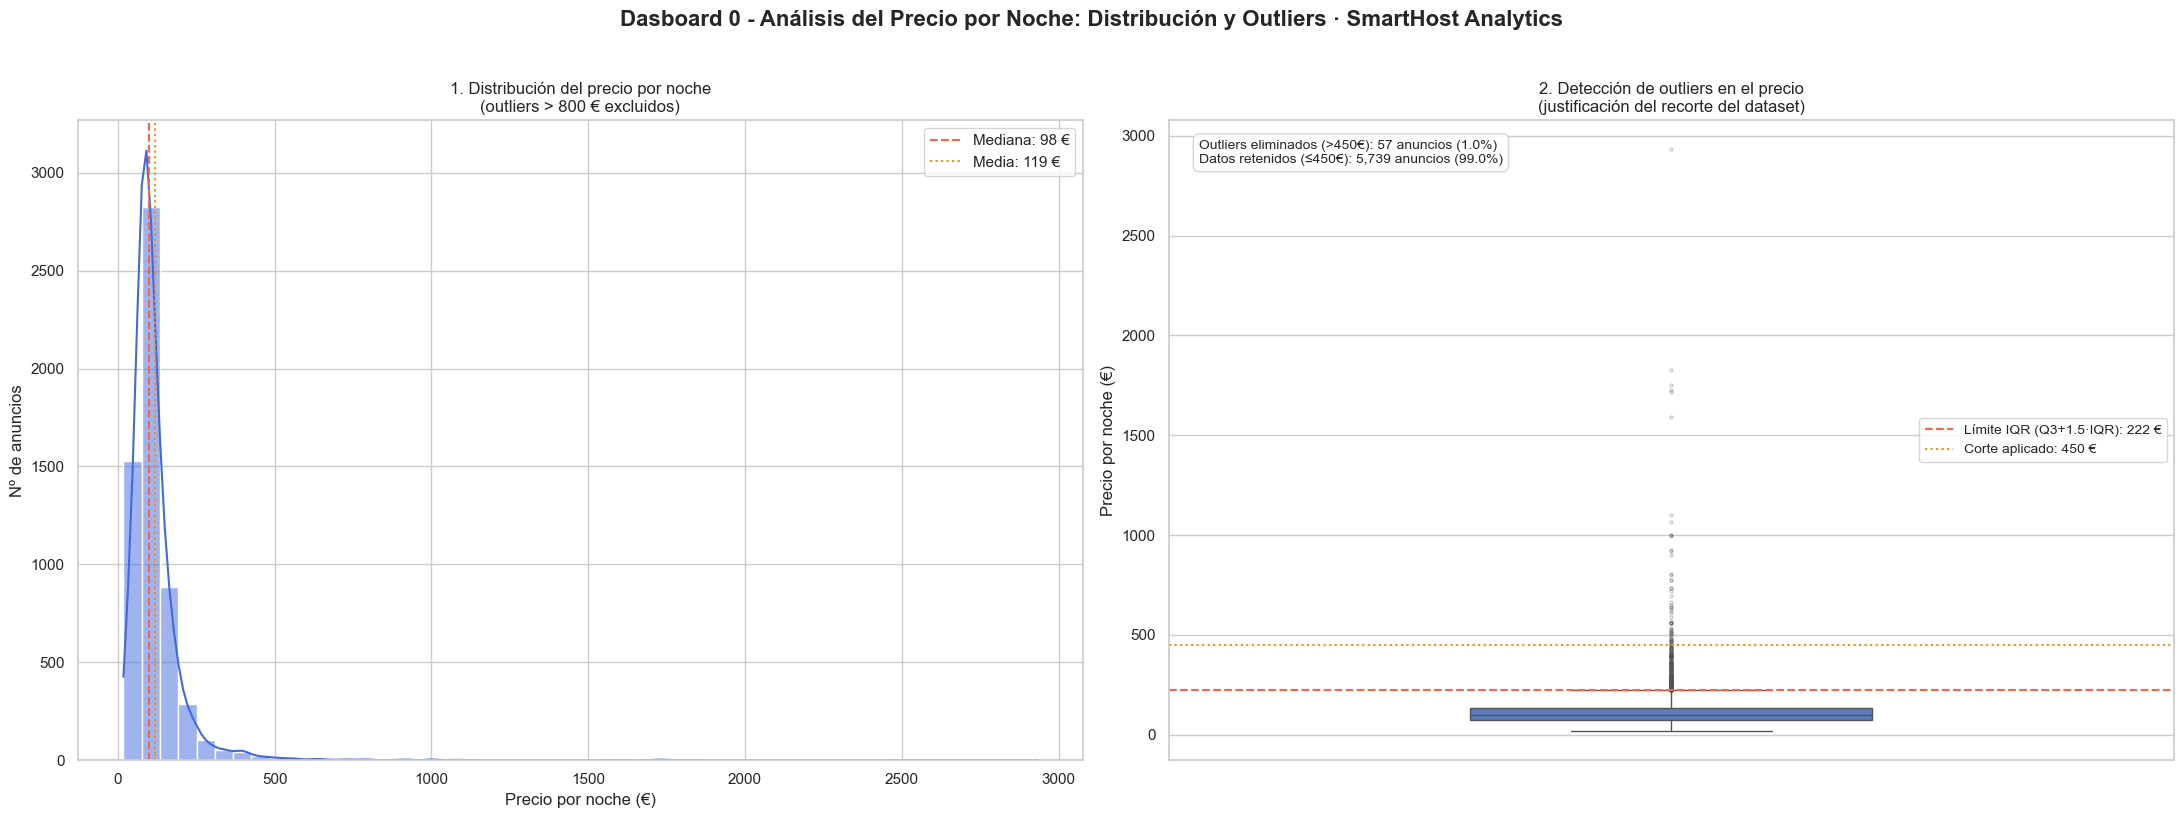

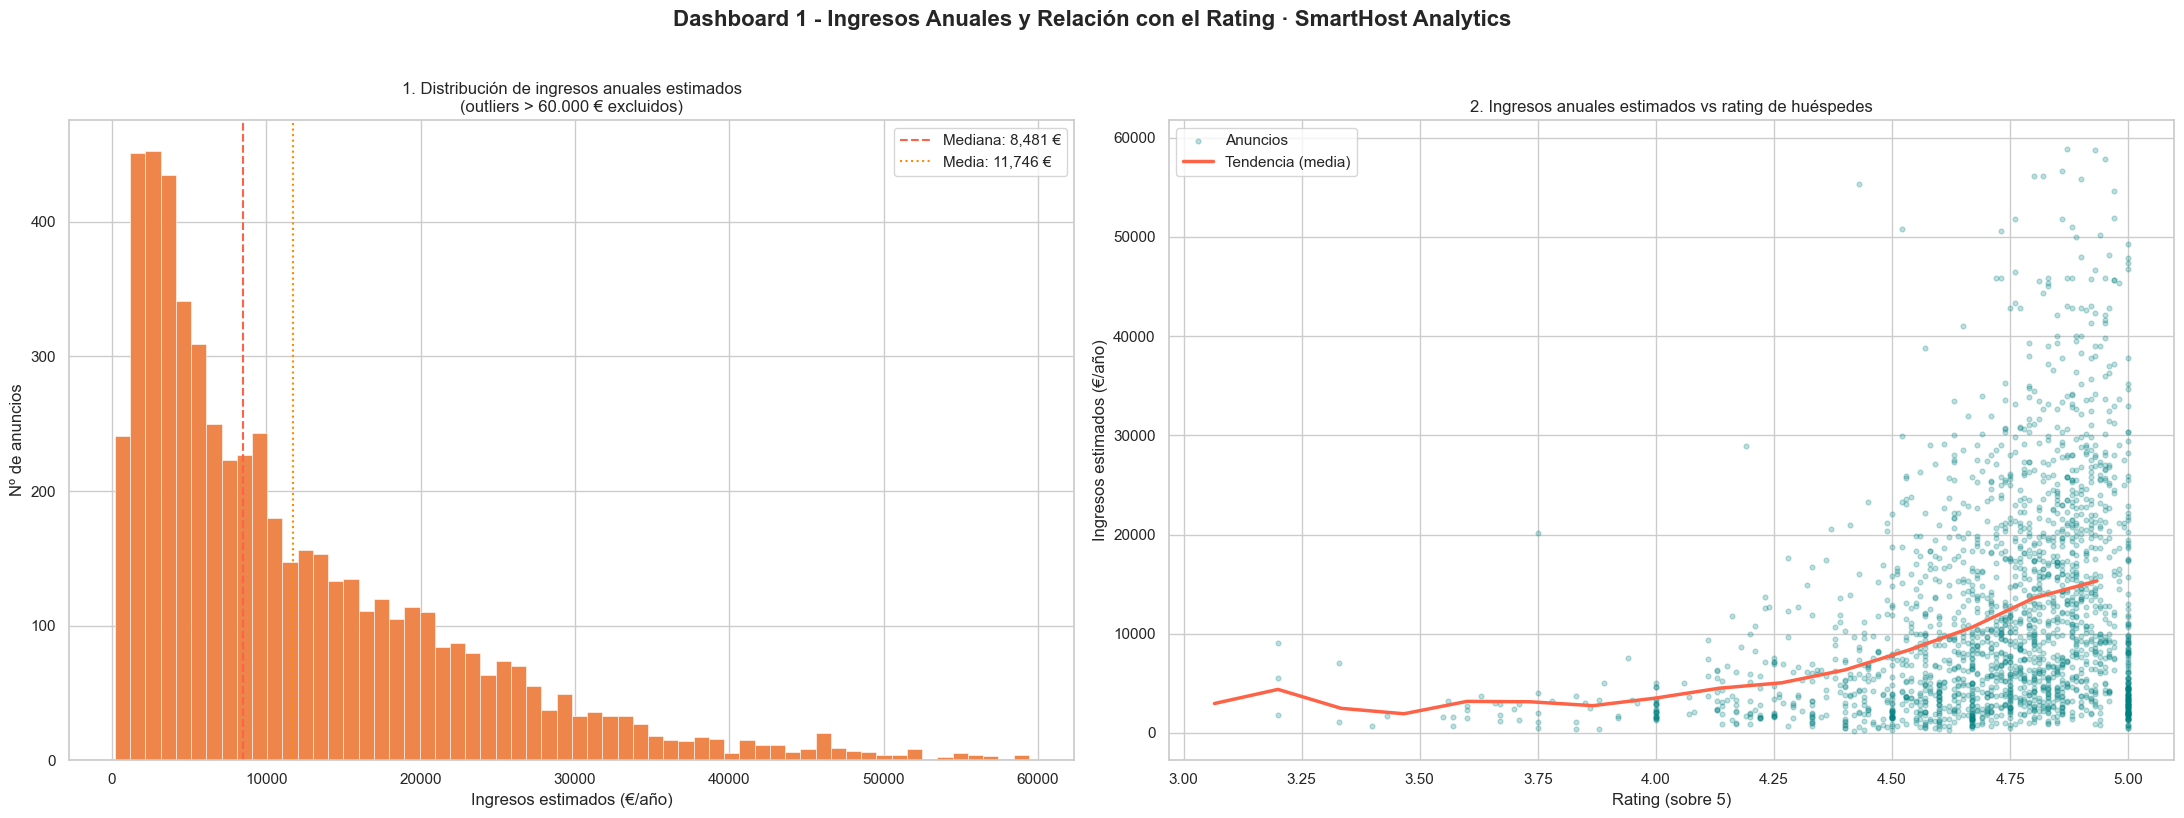

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# ── Preparación de datos ──────────────────────────────────────────────────────
df_vis   = df[df['price'].between(10, 450)].copy()
df_raw   = df[df["price"] > 0].copy()
rev_clip = df["estimated_revenue_l365d"][df["estimated_revenue_l365d"].between(1, 60000)]
df_rv    = df[df["estimated_revenue_l365d"].between(1, 60000) &
                df["review_scores_rating"].between(3, 5)].copy()
sample_r = df_rv.sample(min(2000, len(df_rv)), random_state=42)

Q1  = df_raw["price"].quantile(0.25)
Q3  = df_raw["price"].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR

# ════════════════════════════════════════════════════════════
# FIGURA A — Justificación del filtro de outliers en precio
# ════════════════════════════════════════════════════════════
fig_a, axes_a = plt.subplots(1, 2, figsize=(22, 8))
fig_a.suptitle('Dasboard 0 - Análisis del Precio por Noche: Distribución y Outliers · SmartHost Analytics',
                fontsize=16, fontweight='bold', y=1.02)

# ── Gráfico A1: Histograma precio filtrado ────────────────────────────────────
sns.histplot(df['price'], bins=50, kde=True, ax=axes_a[0], color='royalblue')
axes_a[0].axvline(df['price'].median(), color='tomato', linestyle='--', linewidth=1.5,
                    label=f"Mediana: {df['price'].median():.0f} €")
axes_a[0].axvline(df['price'].mean(), color='darkorange', linestyle=':', linewidth=1.5,
                    label=f"Media: {df['price'].mean():.0f} €")
axes_a[0].set_title('1. Distribución del precio por noche\n(outliers > 800 € excluidos)')
axes_a[0].set_xlabel('Precio por noche (€)')
axes_a[0].set_ylabel('Nº de anuncios')
axes_a[0].legend()

# ── Gráfico A2: Boxplot sin filtrar — detección de outliers ──────────────────
sns.boxplot(data=df_raw, y="price",
            color=sns.color_palette("muted")[0], width=0.4,
            flierprops=dict(marker='.', alpha=0.3, markersize=4),
            ax=axes_a[1])
axes_a[1].axhline(lim_sup, color='tomato', linestyle='--', linewidth=1.5,
                    label=f'Límite IQR (Q3+1.5·IQR): {lim_sup:.0f} €')
axes_a[1].axhline(450, color='darkorange', linestyle=':', linewidth=1.5,
                    label='Corte aplicado: 450 €')

n_outliers = (df_raw["price"] > 450).sum()
pct_out    = n_outliers / len(df_raw) * 100
n_validos  = (df_raw["price"] <= 450).sum()

axes_a[1].text(0.03, 0.97,
                f'Outliers eliminados (>450€): {n_outliers} anuncios ({pct_out:.1f}%)\n'
                f'Datos retenidos (≤450€): {n_validos:,} anuncios ({100-pct_out:.1f}%)',
                transform=axes_a[1].transAxes,
                va='top', ha='left', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                        edgecolor='lightgray', alpha=0.9))
axes_a[1].set_title('2. Detección de outliers en el precio\n(justificación del recorte del dataset)')
axes_a[1].set_xlabel('')
axes_a[1].set_ylabel('Precio por noche (€)')
axes_a[1].legend(loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig('../data/dashboard0_precio_outliers.png', dpi=300)
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURA B — Ingresos anuales e impacto del rating
# ════════════════════════════════════════════════════════════
fig_b, axes_b = plt.subplots(1, 2, figsize=(22, 8))
fig_b.suptitle('Dashboard 1 - Ingresos Anuales y Relación con el Rating · SmartHost Analytics',
                fontsize=16, fontweight='bold', y=1.02)

# ── Gráfico B1: Histograma ingresos anuales ───────────────────────────────────
axes_b[0].hist(rev_clip, bins=60, edgecolor='white', linewidth=0.4,
                color=sns.color_palette('muted')[1])
axes_b[0].axvline(rev_clip.median(), color='tomato', linestyle='--', linewidth=1.5,
                    label=f"Mediana: {rev_clip.median():,.0f} €")
axes_b[0].axvline(rev_clip.mean(), color='darkorange', linestyle=':', linewidth=1.5,
                    label=f"Media: {rev_clip.mean():,.0f} €")
axes_b[0].set_title('1. Distribución de ingresos anuales estimados\n(outliers > 60.000 € excluidos)')
axes_b[0].set_xlabel('Ingresos estimados (€/año)')
axes_b[0].set_ylabel('Nº de anuncios')
axes_b[0].legend()

# ── Gráfico B2: Scatter ingresos vs rating ────────────────────────────────────
axes_b[1].scatter(sample_r['review_scores_rating'], sample_r['estimated_revenue_l365d'],
                    alpha=0.25, s=12, color='teal', label='Anuncios')
trend_r = df_rv.groupby(
    pd.cut(df_rv['review_scores_rating'], bins=15), observed=True
)['estimated_revenue_l365d'].mean().reset_index()
trend_r['x'] = trend_r['review_scores_rating'].apply(lambda b: b.mid)
axes_b[1].plot(trend_r['x'], trend_r['estimated_revenue_l365d'],
                color='tomato', linewidth=2.5, label='Tendencia (media)')
axes_b[1].set_title('2. Ingresos anuales estimados vs rating de huéspedes')
axes_b[1].set_xlabel('Rating (sobre 5)')
axes_b[1].set_ylabel('Ingresos estimados (€/año)')
axes_b[1].legend()

plt.tight_layout()
plt.savefig('../data/dashboard0_ingresos_rating.png', dpi=300)
plt.show()

In [3]:
import pandas as pd

df = pd.read_csv('../data/listingV5.csv') # Carga de datos

# Seaprar features y target
X = df.drop(columns=['price'])
y = df['price']

precios = pd.Series(y)

# --- Estadísticas descriptivas ---
print(precios.describe(percentiles=[.25, .50, .75, .90, .95, .99]))
print(f"\nPisos > 300€: {(precios > 300).sum()} ({(precios > 300).mean()*100:.1f}%)")
print(f"Pisos > 400€: {(precios > 400).sum()} ({(precios > 400).mean()*100:.1f}%)")
print(f"Pisos > 450€: {(precios > 450).sum()} ({(precios > 450).mean()*100:.1f}%)")
print(f"Pisos > 500€: {(precios > 500).sum()} ({(precios > 500).mean()*100:.1f}%)")
print(f"Pisos > 600€: {(precios > 600).sum()} ({(precios > 600).mean()*100:.1f}%)")

count    5796.000000
mean      118.566425
std       100.556774
min        18.000000
25%        75.000000
50%        98.000000
75%       134.000000
90%       189.000000
95%       246.000000
99%       450.000000
max      2932.000000
Name: price, dtype: float64

Pisos > 300€: 174 (3.0%)
Pisos > 400€: 84 (1.4%)
Pisos > 450€: 57 (1.0%)
Pisos > 500€: 44 (0.8%)
Pisos > 600€: 29 (0.5%)


### Dashboard 0 - Justificación metodológica del filtro de precios

El histograma de la izquierda muestra el precio por noche **con todos los datos del dataset**. La gran mayoría de los anuncios se concentra entre 0 y 300 €/noche, pero una minoría de registros alcanza valores de 1.500, 2.000 e incluso 3.000 €/noche. El efecto visual es devastador para el análisis — la escala del eje X se estira para acomodar esos valores extremos y el 99% de los datos queda aplastado en el margen izquierdo, haciendo imposible leer tendencias, modas o distribuciones reales.

El boxplot de la derecha **cuantifica y formaliza** este problema. El límite estadístico IQR (Q3 + 1.5·IQR) se sitúa en **222 €**, lo que significa que matemáticamente cualquier precio por encima ya es un outlier. Sin embargo, dado que el mercado de alquiler vacacional incluye legítimamente apartamentos de alto standing a precios superiores, se aplica un criterio más permisivo: **corte en 450 €/noche**. Decisión tomada en cuánto a sólo 1% del dataset (57 apartamentos) se encuentran por encima de él como podemos ver en las estadísticas de los precios.

> **Decisión metodológica adoptada:** Se eliminan **57 anuncios (1%)** con precio superior a 800 €/noche, reteniendo el 99% para el EDA y el entrenamiento. Esta decisión es conservadora, trazable y reproducible a partir del boxplot. A efectos prácticos del modelo, un sistema de predicción de precios para anfitriones estándar no necesita cubrir el segmento de villas a 3.000 €/noche — ese es un nicho diferente con dinámicas propias.

> **Nota sobre la asimetría:** La diferencia entre la **mediana (98 €)** y la **media (119 €)** — una brecha de 21 € — es un indicador directo del grado de asimetría de la distribución. La media está inflada por los valores altos incluso después del filtro, lo que refuerza que el modelo debería entrenarse con el precio en escala logarítmica o que la mediana es una métrica más representativa del mercado real que la media.

---

## Dashboard 1 - Ingresos Anuales y Relación con el Rating

---

### 1. Distribución de ingresos anuales: un mercado muy desigual

El histograma de ingresos muestra la misma asimetría que el precio, pero **más pronunciada**: el pico máximo se sitúa en el primer bin (0-1.000 €/año), y la distribución cae de forma casi exponencial. La **mediana de 8.481 €/año** frente a una **media de 11.746 €/año** revela una brecha de más de 3.000 € — mucho mayor en términos relativos que la del precio.

Esto indica que el mercado Airbnb de Málaga está profundamente segmentado: un grupo numeroso de anfitriones obtiene ingresos modestos (posiblemente pisos alquilados ocasionalmente o con baja ocupación), mientras que una minoría con alta ocupación y buena reputación genera ingresos anuales muy superiores que elevan la media.

> **Hipótesis:** La variable `estimated_revenue_l365d` es más difícil de predecir que el `price` porque incorpora implícitamente la **tasa de ocupación**, que a su vez depende de factores dinámicos como la reputación del anfitrión, la estacionalidad, la política de precios y la capacidad de respuesta. La red neuronal tendrá mayor error relativo en este target que en el precio.

---

### 2. Ingresos vs rating: la calidad se traduce en rentabilidad

El scatter plot revela una relación que va más allá de lo intuitivo. Para ratings bajos (3.0 - 4.0), los ingresos son escasos y muy homogéneos — la nube de puntos es densa y plana cerca del cero. A partir de **4.25-4.50**, la dispersión vertical se dispara y la tendencia media comienza a crecer de forma notable. Para ratings cercanos a **5.0**, los ingresos máximos alcanzan los 60.000 €/año y la media supera los 15.000 €.

La forma de la tendencia no es lineal sino **exponencial a partir de un umbral**: ratings mediocres no generan diferencias apreciables, pero el salto de 4.5 a 5.0 en rating tiene un impacto económico desproporcionadamente alto.

> **Hipótesis:** El rating no solo afecta al precio que puede cobrar el anfitrión, sino sobre todo a la **visibilidad dentro del algoritmo de Airbnb** — los anuncios mejor valorados aparecen primero en las búsquedas, lo que amplifica su ocupación y, por tanto, sus ingresos anuales. Es un efecto multiplicador que explica por qué la relación es exponencial y no lineal.

> **Implicación para el modelo:** `review_scores_rating` es una de las features más importantes para predecir los **ingresos anuales**, aunque su impacto es asimétrico (importa más en el rango alto). Para el precio por noche su importancia es menor — un piso mal valorado puede seguir cobrando 100 €/noche, pero difícilmente mantendrá 200+ noches ocupadas al año. Esta distinción justifica plenamente que SmartHost Analytics trate ambas variables como **targets independientes** con dinámicas propias.

---

### 📌 Decisiones metodológicas derivadas del Dashboard 0 y 1

| Decisión | Justificación |
|---|---|
| Filtro precio ≤ 450 €/noche en EDA | Elimina 1% de registros, hace legibles el 99.0% restante |
| Filtro ingresos ≤ 60.000 €/año | Mismo criterio: outliers extremos con nula representatividad |
| Dos targets independientes (`price` y `revenue`) | Dinámicas distintas: precio ≠ rentabilidad |
| `review_scores_rating` como feature clave | Impacto exponencial en ingresos confirmado visualmente |

### DASHBOARD 2 - Características piso

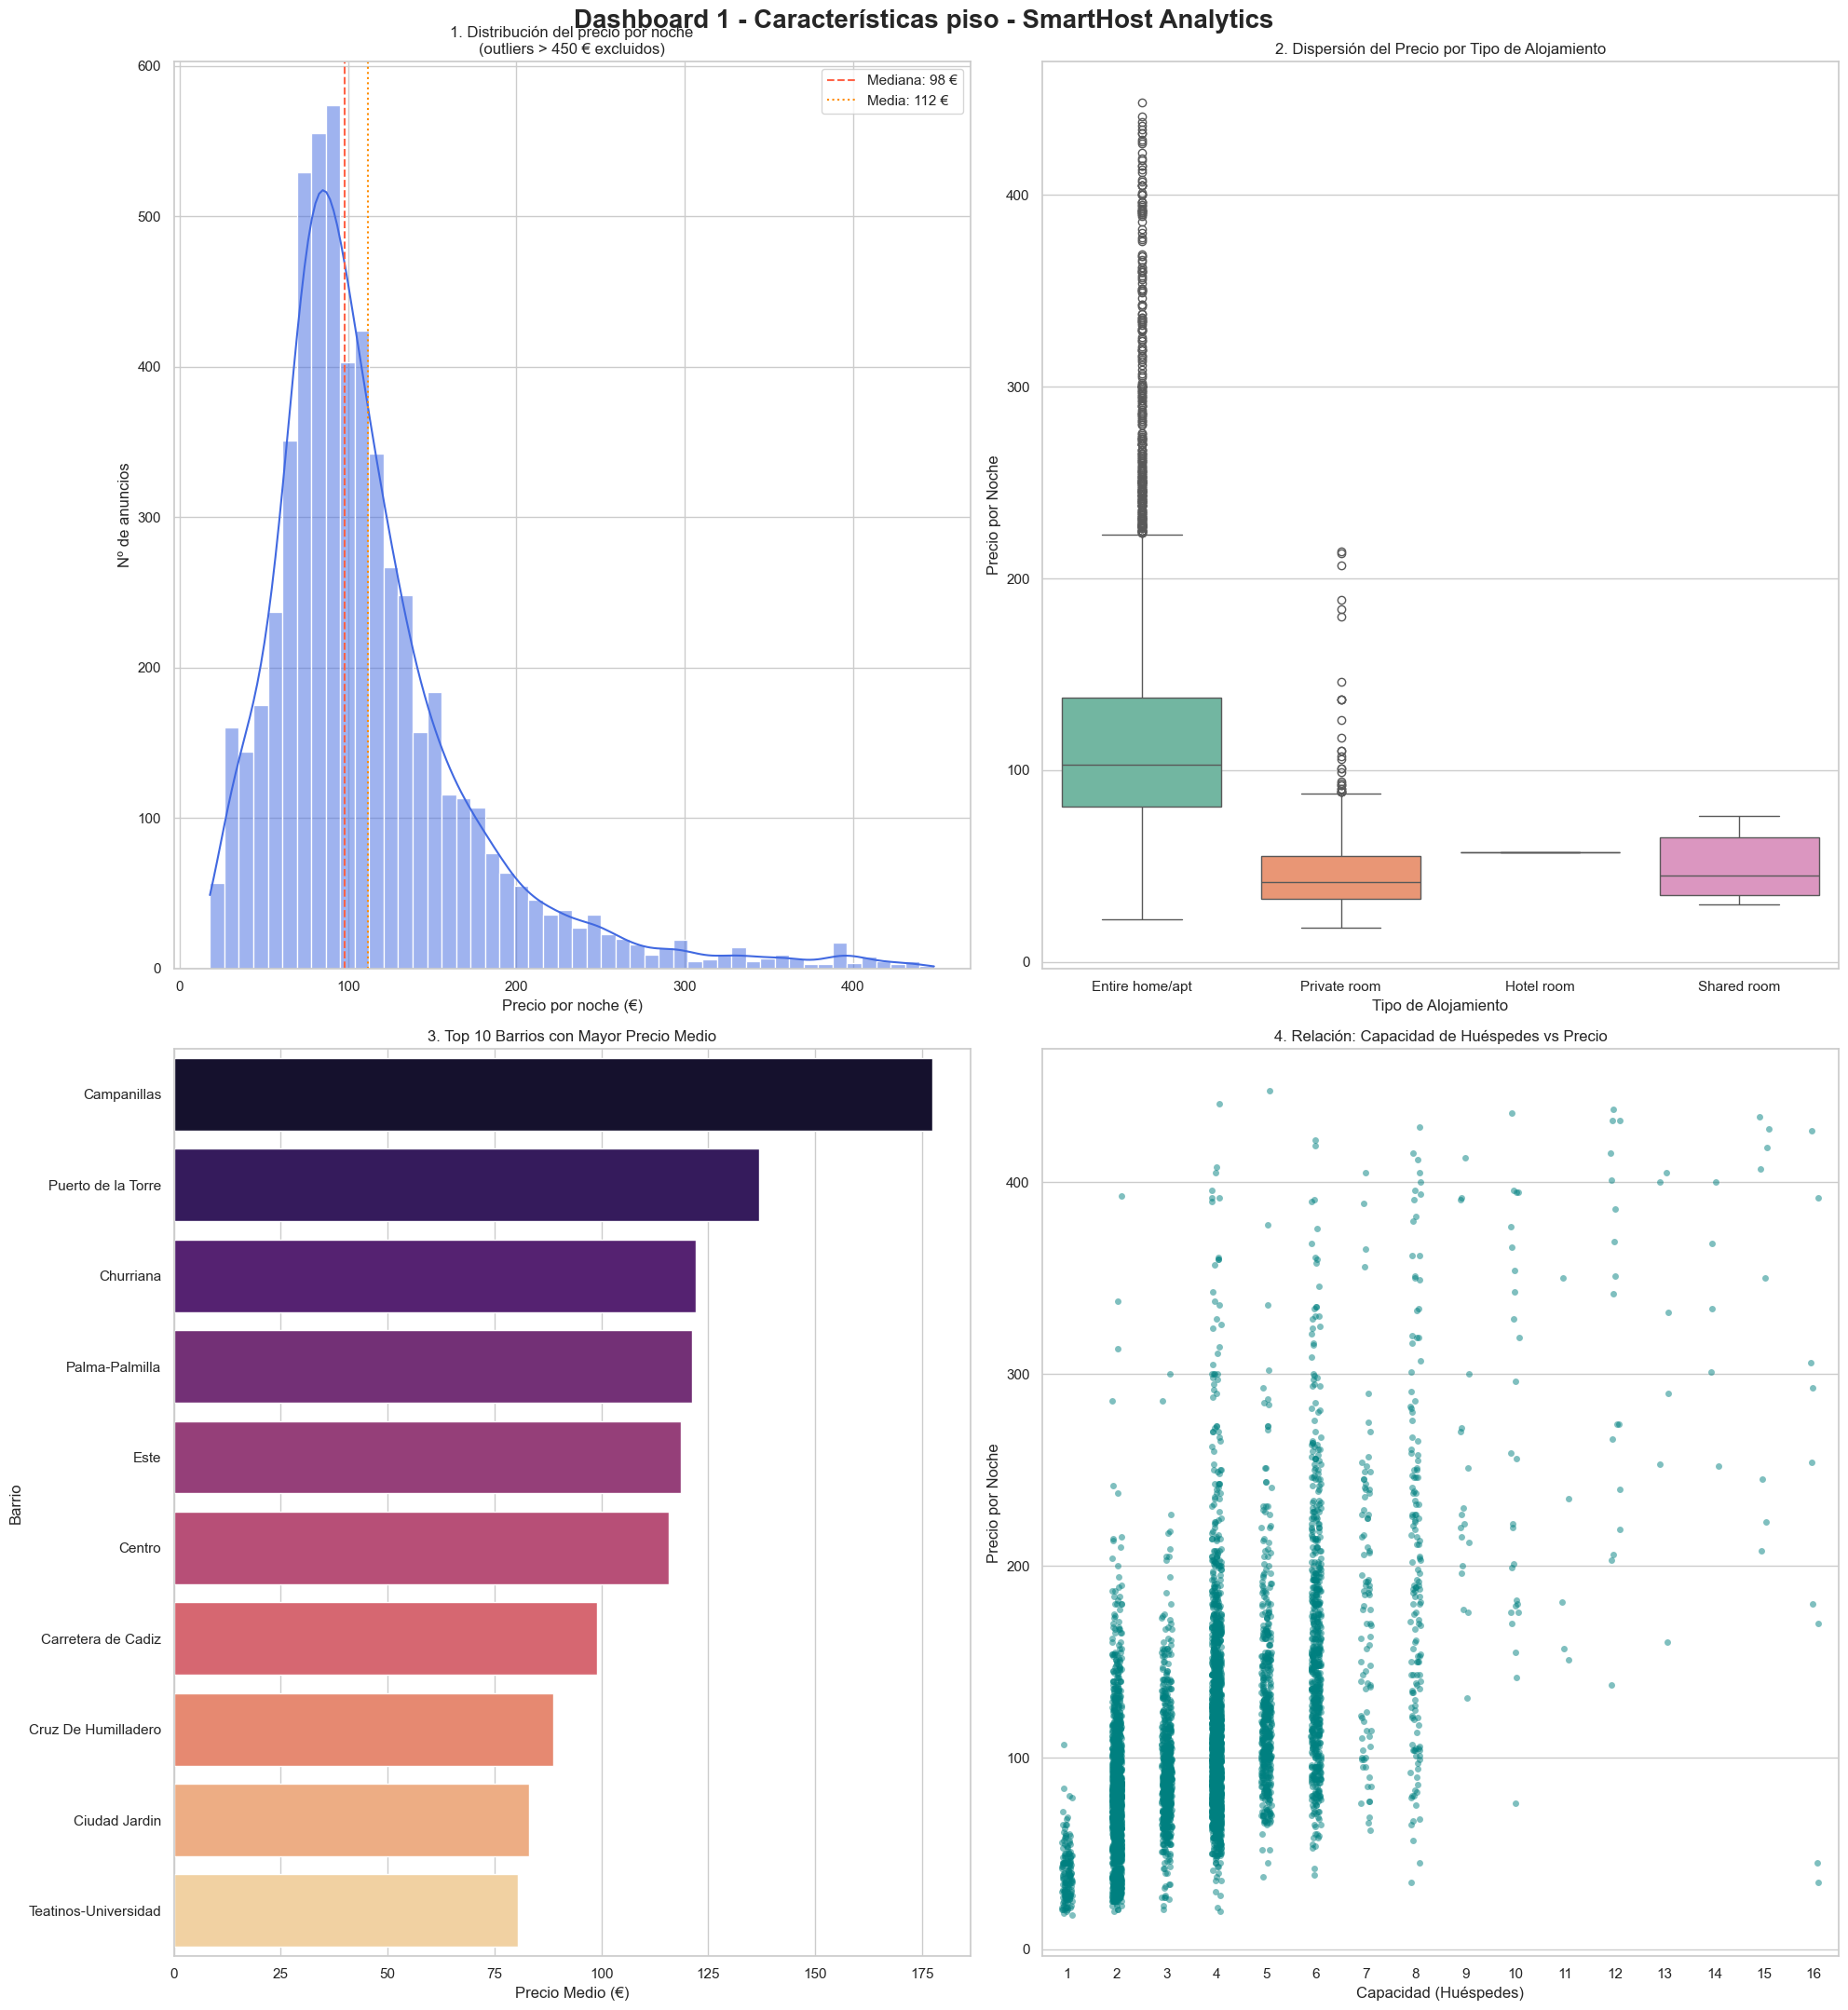

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# Filtrar outliers para visualización
df_vis = df[df['price'] < 450]

# Crear el lienzo
fig, axes = plt.subplots(2, 2, figsize=(20, 22))
fig.suptitle('Dashboard 1 - Características piso - SmartHost Analytics',
            fontsize=20, fontweight='bold', y=0.98)

# =========================================================
# GRÁFICA 1: Histograma - Distribución del Target
# =========================================================
sns.histplot(df_vis['price'], bins=50, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].axvline(df_vis['price'].median(), color='tomato', linestyle='--', linewidth=1.5,
                    label=f"Mediana: {df_vis['price'].median():.0f} €")
axes[0, 0].axvline(df_vis['price'].mean(), color='darkorange', linestyle=':', linewidth=1.5,
                    label=f"Media: {df_vis['price'].mean():.0f} €")
axes[0, 0].set_title('1. Distribución del precio por noche\n(outliers > 450 € excluidos)')
axes[0, 0].set_xlabel('Precio por noche (€)')
axes[0, 0].set_ylabel('Nº de anuncios')
axes[0, 0].legend()

# =========================================================
# GRÁFICA 2: Boxplot - Precio según Tipo de Habitación
# =========================================================
sns.boxplot(x='room_type', y='price', data=df_vis,
            hue='room_type', palette='Set2', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('2. Dispersión del Precio por Tipo de Alojamiento')
axes[0, 1].set_xlabel('Tipo de Alojamiento')
axes[0, 1].set_ylabel('Precio por Noche')

# =========================================================
# GRÁFICA 3: Barras - Top 10 Barrios Más Caros
# =========================================================
top_barrios = (df_vis.groupby('neighbourhood_cleansed')['price']
                .mean().sort_values(ascending=False).head(10).reset_index())
sns.barplot(x='price', y='neighbourhood_cleansed', data=top_barrios,
            hue='neighbourhood_cleansed', palette='magma', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. Top 10 Barrios con Mayor Precio Medio')
axes[1, 0].set_xlabel('Precio Medio (€)')
axes[1, 0].set_ylabel('Barrio')

# =========================================================
# GRÁFICA 4: Scatter - Capacidad vs Precio
# =========================================================
sns.stripplot(x='accommodates', y='price', data=df_vis,
                alpha=0.5, jitter=True, color='teal', ax=axes[1, 1])
axes[1, 1].set_title('4. Relación: Capacidad de Huéspedes vs Precio')
axes[1, 1].set_xlabel('Capacidad (Huéspedes)')
axes[1, 1].set_ylabel('Precio por Noche')

plt.tight_layout()
plt.savefig('../data/Dashboard1_Caracteristicas_Piso.png', dpi=300)
plt.show()

## Dashboard 2 - Características Airbnb´s

---

### 1. Histograma precio vs Cantidad apartamentos

La mayoría de apartamentos se encuentran entre los 50 y 140€/noche aprox

> **Hipótesis:** Entre estos precios se encontrarán la mayoría de apartamentos que se dedican profesionalmente al turismo, ya que son precios competitivos para obtener un buen beneficio y tener ocupado el apartamento la mayoría del año.

---

### 2. Boxplot por tipo de apartamento

Este gráfico nos da a entender como un apartamento entero siempre tendrá un precio claramento superior a un apartamento compartido o una habitación privada (Que suelen tener estancias compartidas también, por ello vemos precios parejos entre private room y shared rooms).


---

### 3. Top 10 barrios con mayor precio

Este histograma muestra el top 10 de barrios ordenados en función a su precio medio por noche.

---

### 4. Capacidad huéspedes vs precio

A mayor capacidad de huéspedes, el precio mínimo por noche aumenta, la mayoría de apartamentos existentes se sitúan en 1-6 huéspedes de capacidad.

> **Hipótesis:** La mayoría de apartamentos se sitúan de 1 a 6 huéspedes, probablemente por qué la amyoría son estudios o apartamentos de 1 o 2 habitaciones, lógicamente el precio a mediada que aumentan las personas alojadas aumenta.

---


### Dashboard 3 - Geografía y ubicación

C:\Users\david\AppData\Local\Temp\ipykernel_17784\3485702681.py:103: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


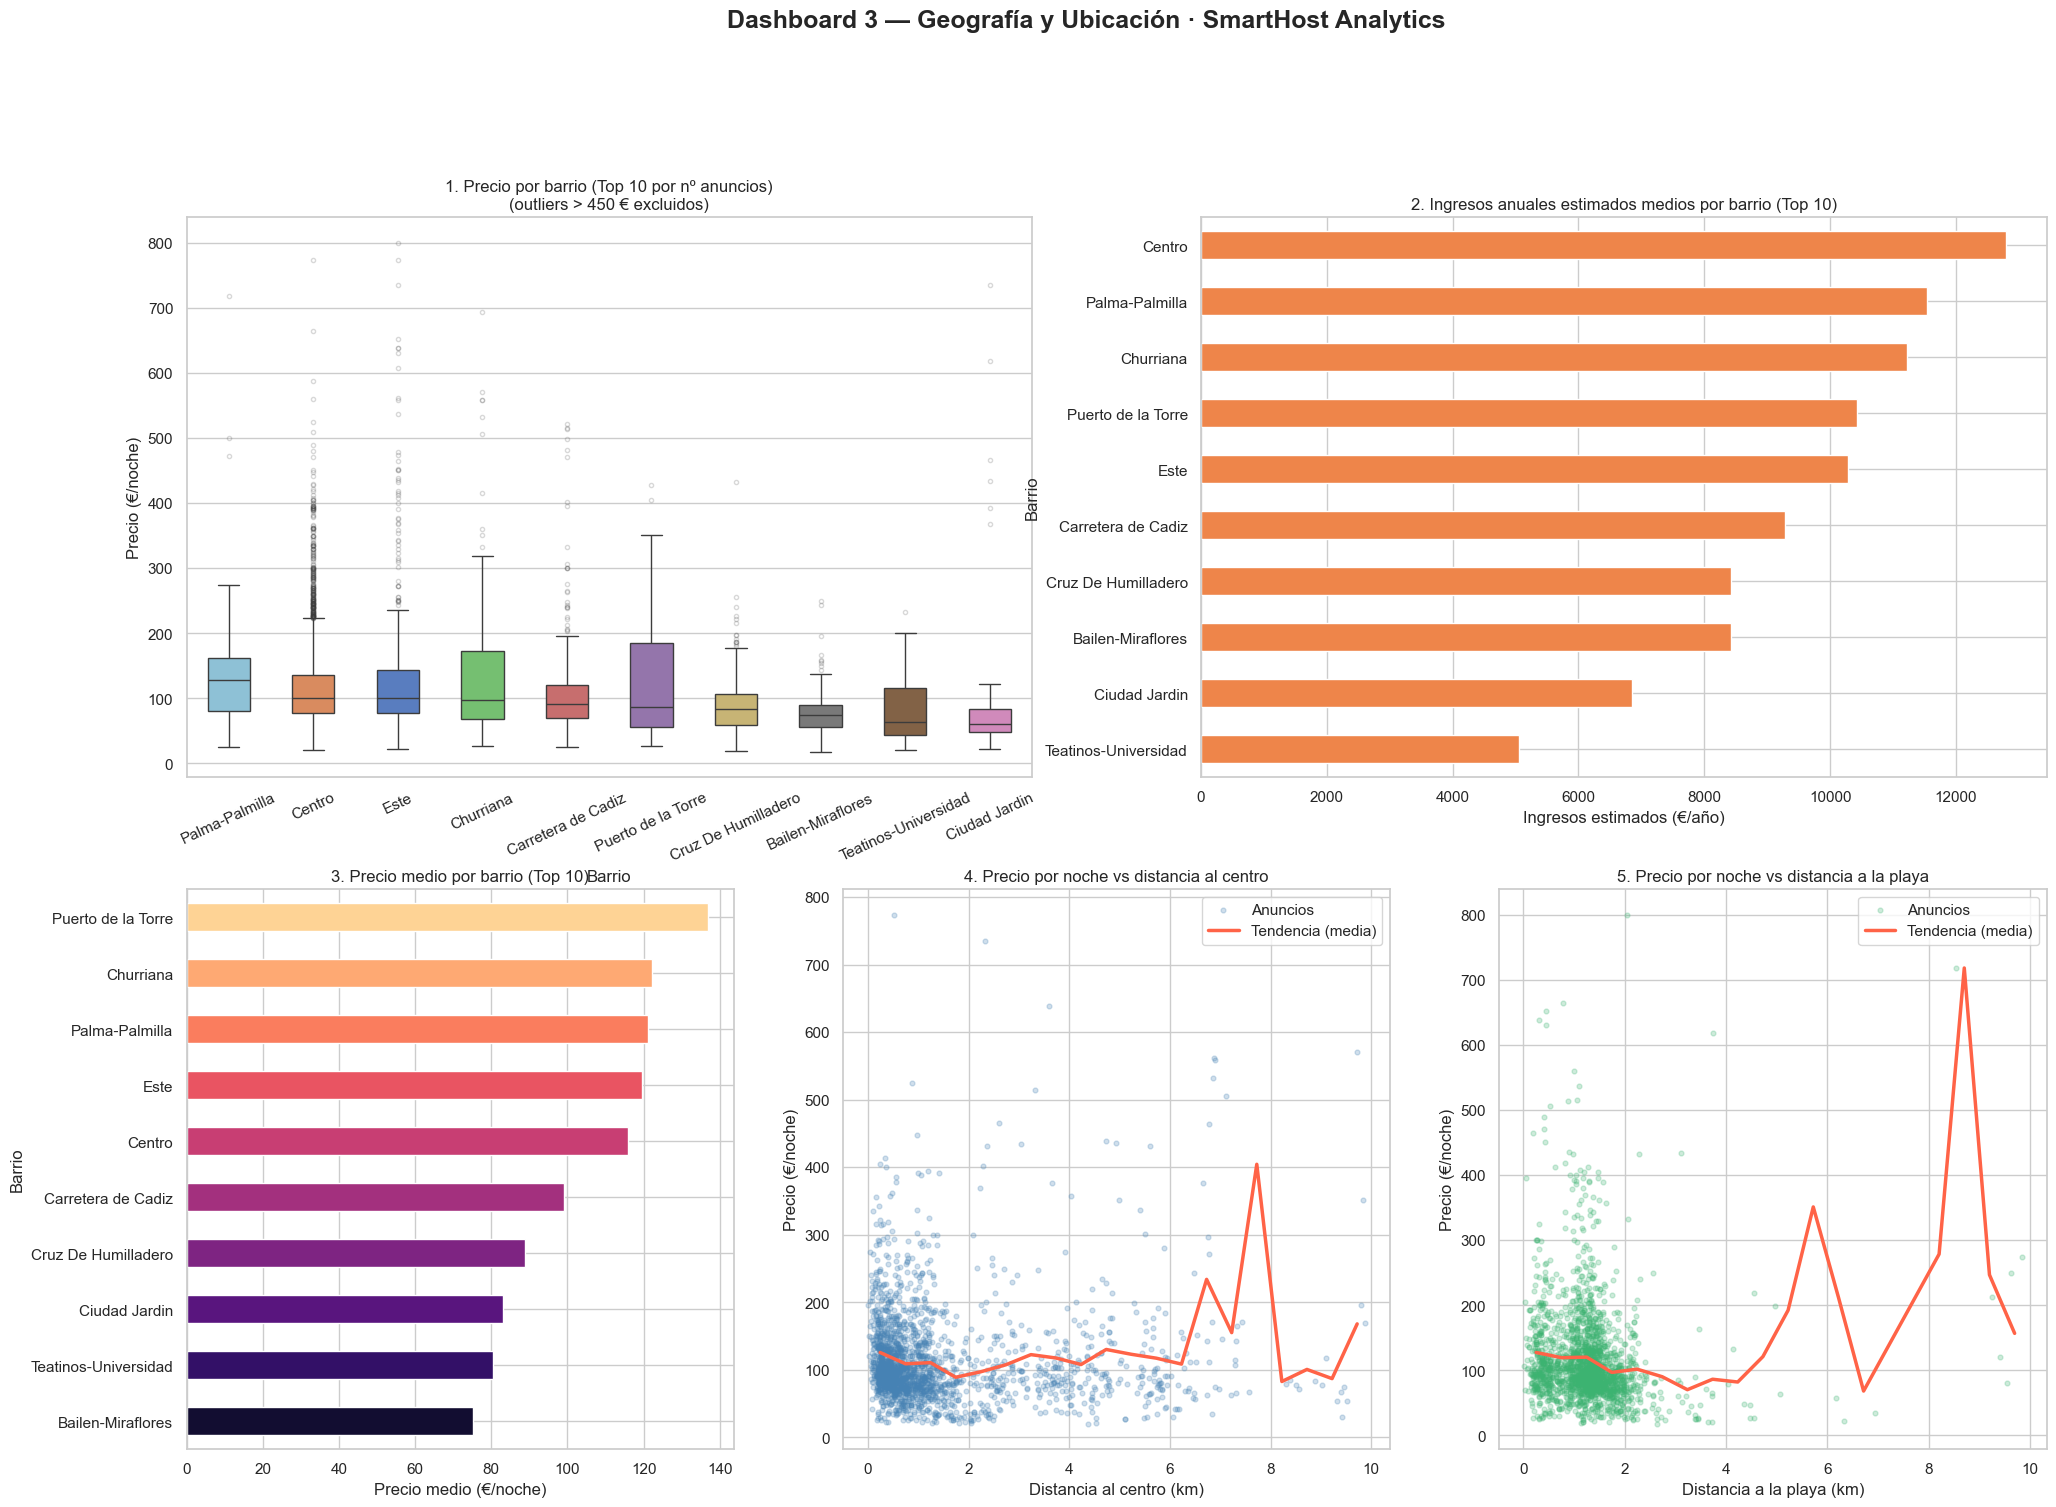

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# ── Preparación de datos ──────────────────────────────────────────────────────
top10 = df["neighbourhood_cleansed"].value_counts().head(10).index
df_bar = df[df["neighbourhood_cleansed"].isin(top10) & df["price"].between(10, 800)].copy()
order_b = (df_bar.groupby("neighbourhood_cleansed")["price"]
            .median().sort_values(ascending=False).index.tolist())

df_sc = df[df["price"].between(10, 800) & df["distancia_centro_km"].between(0, 10)].copy()
df_pl = df[df["price"].between(10, 800) & df["distancia_playa_km"].between(0, 10)].copy()
sample    = df_sc.sample(2000, random_state=42)
sample_pl = df_pl.sample(min(2000, len(df_pl)), random_state=42)

# ── Lienzo: fila superior 2 cols, fila inferior 3 cols ───────────────────────
fig = plt.figure(figsize=(24, 16))
fig.suptitle('Dashboard 3 — Geografía y Ubicación · SmartHost Analytics',
            fontsize=18, fontweight='bold', y=1.01)

ax1 = fig.add_subplot(2, 2, 1)   # Boxplot barrios
ax2 = fig.add_subplot(2, 2, 2)   # Ingresos barrios
ax3 = fig.add_subplot(2, 3, 4)   # Precio medio barrios
ax4 = fig.add_subplot(2, 3, 5)   # Scatter distancia centro
ax5 = fig.add_subplot(2, 3, 6)   # Scatter distancia playa

# =========================================================
# GRÁFICA 1: Boxplot precio por barrio (Top 10)
# =========================================================
sns.boxplot(data=df_bar, x="neighbourhood_cleansed", y="price", order=order_b,
            hue="neighbourhood_cleansed", palette="muted", width=0.5,
            flierprops=dict(marker=".", alpha=0.2), legend=False, ax=ax1)
ax1.set_title("1. Precio por barrio (Top 10 por nº anuncios)\n(outliers > 450 € excluidos)")
ax1.set_xlabel("Barrio")
ax1.set_ylabel("Precio (€/noche)")
ax1.tick_params(axis="x", rotation=25)

# =========================================================
# GRÁFICA 2: Ingresos anuales medios por barrio (Top 10)
# =========================================================
rev_barrio = (
    df[df["neighbourhood_cleansed"].isin(top10) & df["estimated_revenue_l365d"].between(1, 60000)]
    .groupby("neighbourhood_cleansed")["estimated_revenue_l365d"]
    .mean()
    .sort_values(ascending=True)
)
rev_barrio.plot(kind="barh", ax=ax2,
                color=sns.color_palette("muted")[1], edgecolor="white")
ax2.set_title("2. Ingresos anuales estimados medios por barrio (Top 10)")
ax2.set_xlabel("Ingresos estimados (€/año)")
ax2.set_ylabel("Barrio")

# =========================================================
# GRÁFICA 3: Precio medio por barrio (barras horizontales)
# =========================================================
top_precio = (
    df[df["neighbourhood_cleansed"].isin(top10) & df["price"].between(10, 450)]
    .groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=True)
)
top_precio.plot(kind="barh", ax=ax3,
                color=sns.color_palette("magma", len(top_precio)), edgecolor="white")
ax3.set_title("3. Precio medio por barrio (Top 10)")
ax3.set_xlabel("Precio medio (€/noche)")
ax3.set_ylabel("Barrio")

# =========================================================
# GRÁFICA 4: Scatter precio vs distancia al centro
# =========================================================
ax4.scatter(sample["distancia_centro_km"], sample["price"],
            alpha=0.25, s=12, color="steelblue", label="Anuncios")
bins_c = pd.cut(df_sc["distancia_centro_km"], bins=20)
trend_c = df_sc.groupby(bins_c, observed=True)["price"].mean().reset_index()
trend_c["x"] = trend_c["distancia_centro_km"].apply(lambda b: b.mid)
ax4.plot(trend_c["x"], trend_c["price"],
        color="tomato", linewidth=2.5, label="Tendencia (media)")
ax4.set_title("4. Precio por noche vs distancia al centro")
ax4.set_xlabel("Distancia al centro (km)")
ax4.set_ylabel("Precio (€/noche)")
ax4.legend()

# =========================================================
# GRÁFICA 5: Scatter precio vs distancia a la playa
# =========================================================
ax5.scatter(sample_pl["distancia_playa_km"], sample_pl["price"],
            alpha=0.25, s=12, color="mediumseagreen", label="Anuncios")
bins_p = pd.cut(df_pl["distancia_playa_km"], bins=20)
trend_p = df_pl.groupby(bins_p, observed=True)["price"].mean().reset_index()
trend_p["x"] = trend_p["distancia_playa_km"].apply(lambda b: b.mid)
ax5.plot(trend_p["x"], trend_p["price"],
        color="tomato", linewidth=2.5, label="Tendencia (media)")
ax5.set_title("5. Precio por noche vs distancia a la playa")
ax5.set_xlabel("Distancia a la playa (km)")
ax5.set_ylabel("Precio (€/noche)")
ax5.legend()

plt.tight_layout()
plt.savefig('../data/dashboard2_geografia.png', dpi=300)
plt.show()

### Mapa de calor - Área estudiada

In [6]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import json

# ── 1. Cargar el GeoJSON desde archivo local ──────────────────────────────────
with open("../data/neighbourhoods.geojson", "r", encoding="utf-8") as f:
    neighbourhoods_geojson = json.load(f)

print(f"GeoJSON cargado: {len(neighbourhoods_geojson['features'])} barrios")
# ── 2. Preparación de datos ───────────────────────────────────────────────────
df_map = df[df["price"].between(10, 400)].dropna(subset=["latitude", "longitude", "price"]).copy()
df_map["price_norm"] = (df_map["price"] - df_map["price"].min()) / \
                        (df_map["price"].max() - df_map["price"].min())
heat_data = df_map[["latitude", "longitude", "price_norm"]].values.tolist()

# ── 3. Crear el mapa base centrado en Málaga ──────────────────────────────────
mapa = folium.Map(
    location=[df_map["latitude"].mean(), df_map["longitude"].mean()],
    zoom_start=13,
    tiles="CartoDB positron"
)

# ── 4. Añadir el contorno del área estudiada (barrios Inside Airbnb) ──────────
folium.GeoJson(
    neighbourhoods_geojson,
    name="Barrios Inside Airbnb",
    style_function=lambda feature: {
        "fillColor": "#4a90d9",
        "color": "#1a5fa8",       # borde azul oscuro
        "weight": 1.5,
        "fillOpacity": 0.04,      # casi transparente para no tapar el heatmap
        "dashArray": "4 4"        # línea discontinua → indica "área de estudio"
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["neighbourhood"],
        aliases=["Barrio:"],
        style="font-family: Arial; font-size: 12px;"
    )
).add_to(mapa)

# ── 5. Añadir capa de calor de precios ───────────────────────────────────────
HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=15,
    blur=12,
    max_zoom=16,
    gradient={
        0.2: "#313695",
        0.4: "#74add1",
        0.6: "#fee090",
        0.8: "#f46d43",
        1.0: "#a50026"
    }
).add_to(mapa)

# ── 6. Control de capas (activar/desactivar heatmap o barrios) ────────────────
folium.LayerControl().add_to(mapa)

# ── 7. Leyenda ────────────────────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background: white; padding: 14px 18px; border-radius: 8px;
            box-shadow: 2px 2px 8px rgba(0,0,0,0.3); font-family: Arial; font-size: 13px;">
    <b>Precio por noche (€)</b><br>
    <div style="display:flex; align-items:center; margin-top:8px;">
        <div style="width:160px; height:14px;
                    background: linear-gradient(to right, #313695, #74add1, #fee090, #f46d43, #a50026);
                    border-radius:3px; margin-right:8px;"></div>
    </div>
    <div style="display:flex; justify-content:space-between; width:160px;
                font-size:11px; margin-top:3px;">
        <span>10 €</span><span>→</span><span>400 €</span>
    </div>
    <hr style="margin:10px 0; border-color:#ddd;">
    <div style="display:flex; align-items:center; gap:8px; font-size:12px;">
        <div style="width:28px; height:2px; border-top: 2px dashed #1a5fa8;"></div>
        <span>Área de estudio (Inside Airbnb)</span>
    </div>
</div>
"""
mapa.get_root().html.add_child(folium.Element(legend_html))

# ── 8. Mostrar en Jupyter y guardar ──────────────────────────────────────────
display(mapa)
mapa.save("../data/heatmap_precios_malaga.html")
print("Mapa guardado en ../data/heatmap_precios_malaga.html")

GeoJSON cargado: 11 barrios


Mapa guardado en ../data/heatmap_precios_malaga.html


### 1. Concentración geográfica de la oferta

El mapa de calor revela que **la gran mayoría de los anuncios se concentran en el núcleo urbano de Málaga**, especialmente en el triángulo formado por el Centro histórico, el frente litoral (Malagueta - El Palo) y el corredor hacia Churriana. Las zonas periféricas (norte montañoso, municipios del interior) tienen densidad mínima.

> **Hipótesis:** La oferta Airbnb en Málaga responde al patrón clásico de turismo urbano-costero. El visitante tipo busca proximidad al centro histórico (Alcazaba, Catedral, Calle Larios) y/o al mar. Esto implica que **la ubicación es, a priori, la variable con mayor poder predictivo** sobre el precio.

---

### 2. La paradoja del Centro: precio medio moderado con alta dispersión

El boxplot por barrios muestra que **Centro no lidera el ranking de precio medio** — es superado por Palma-Palmilla, Puerto de la Torre, Churriana o Este. Sin embargo, es el barrio con **mayor número de outliers por encima** (precios superiores a 300-400 €/noche).

Esto genera una distribución muy asimétrica con mediana contenida pero cola derecha larga, lo que explica su posición intermedia en el gráfico de precio medio.

> **Hipótesis:** En el Centro coexisten dos segmentos muy distintos:
> - **Segmento bajo/medio:** habitaciones privadas, estudios pequeños y pisos compartidos que compiten por precio y arrastran la mediana hacia abajo.
> - **Segmento alto:** apartamentos de lujo, áticos y propiedades premium en ubicaciones prime (junto a la Catedral, el Puerto) que generan los outliers superiores.
>
> La red neuronal deberá aprender a separar estos dos sub-mercados dentro del mismo barrio — esto justifica incluir variables como `room_type`, `accommodates` y `amenities_score` junto a la variable geográfica.

---

### 3. Barrios periféricos con precio medio alto: el efecto villa/chalet

Barrios como **Churriana, Puerto de la Torre o Palma-Palmilla** tienen precios medios superiores al Centro a pesar de estar más alejados del núcleo turístico. Esto se confirma también en los scatter plots de distancia: a partir de los 6-7 km del centro o la playa, la tendencia media de precio repunta significativamente.

> **Hipótesis:** Los alojamientos más alejados no son pisos turísticos estándar, sino **villas, chalets y casas rurales con alta capacidad** (8-12 huéspedes, piscina, jardín) que justifican un precio por noche elevado. El precio se divide entre más personas, pero el valor absoluto por noche es alto.
>
> Esto sugiere que la variable `price_per_person` y `accommodates` serán especialmente relevantes para la red en estos rangos de distancia. El modelo no debería interpretar "lejos del centro = barato" de forma lineal.

---

### 4. Distancia al centro vs. precio: relación no lineal

El scatter de `distancia_centro_km` muestra una **tendencia en forma de U asimétrica**: el precio medio baja levemente al alejarse del centro en los primeros 4-5 km (zona residencial estándar), pero **repunta con fuerza a partir de los 6-7 km**, coincidiendo con la transición hacia municipios periurbanos con alojamientos de mayor tamaño.

> **Implicación para el modelo:** Una regresión lineal simple sobre `distancia_centro_km` capturaría mal esta relación. Las **redes neuronales con capas ocultas** pueden aprender esta no-linealidad de forma natural, lo que refuerza la elección de arquitectura del proyecto. Alternativamente, podría plantearse una transformación polinómica de esta feature como baseline.

---

### 5. Distancia a la playa: patrón similar con matiz costero

La relación `distancia_playa_km` vs. precio presenta un patrón análogo al del centro, con la salvedad de que **los precios más altos en proximidad a la playa** (0-1 km) son más consistentes y con menos ruido. A mayor distancia, el efecto villa vuelve a aparecer en el extremo derecho.

> **Hipótesis:** La variable `distancia_playa_km` aporta información **complementaria y no redundante** respecto a `distancia_centro_km`, ya que captura el valor del turismo de sol y playa que no está correlacionado con el turismo cultural del centro. Incluir ambas en el modelo está justificado.

---

### 6. Ingresos anuales vs. precio: Centro lidera en rentabilidad real

Aunque el precio medio del Centro no es el más alto, **sí es el barrio con mayores ingresos anuales estimados** (gráfico 2). Esto indica que los apartamentos del centro tienen una **tasa de ocupación significativamente superior** al resto.

> **Hipótesis:** El precio por noche y la rentabilidad anual son variables objetivo con dinámicas diferentes. Un piso en Churriana puede cobrar más por noche, pero permanece vacío más días. Esto justifica que SmartHost Analytics prediga **ambas variables** (`price` y `estimated_revenue_l365d`) en lugar de solo el precio.

---

### Dashboard 4 - Estructura Física del Alojamiento

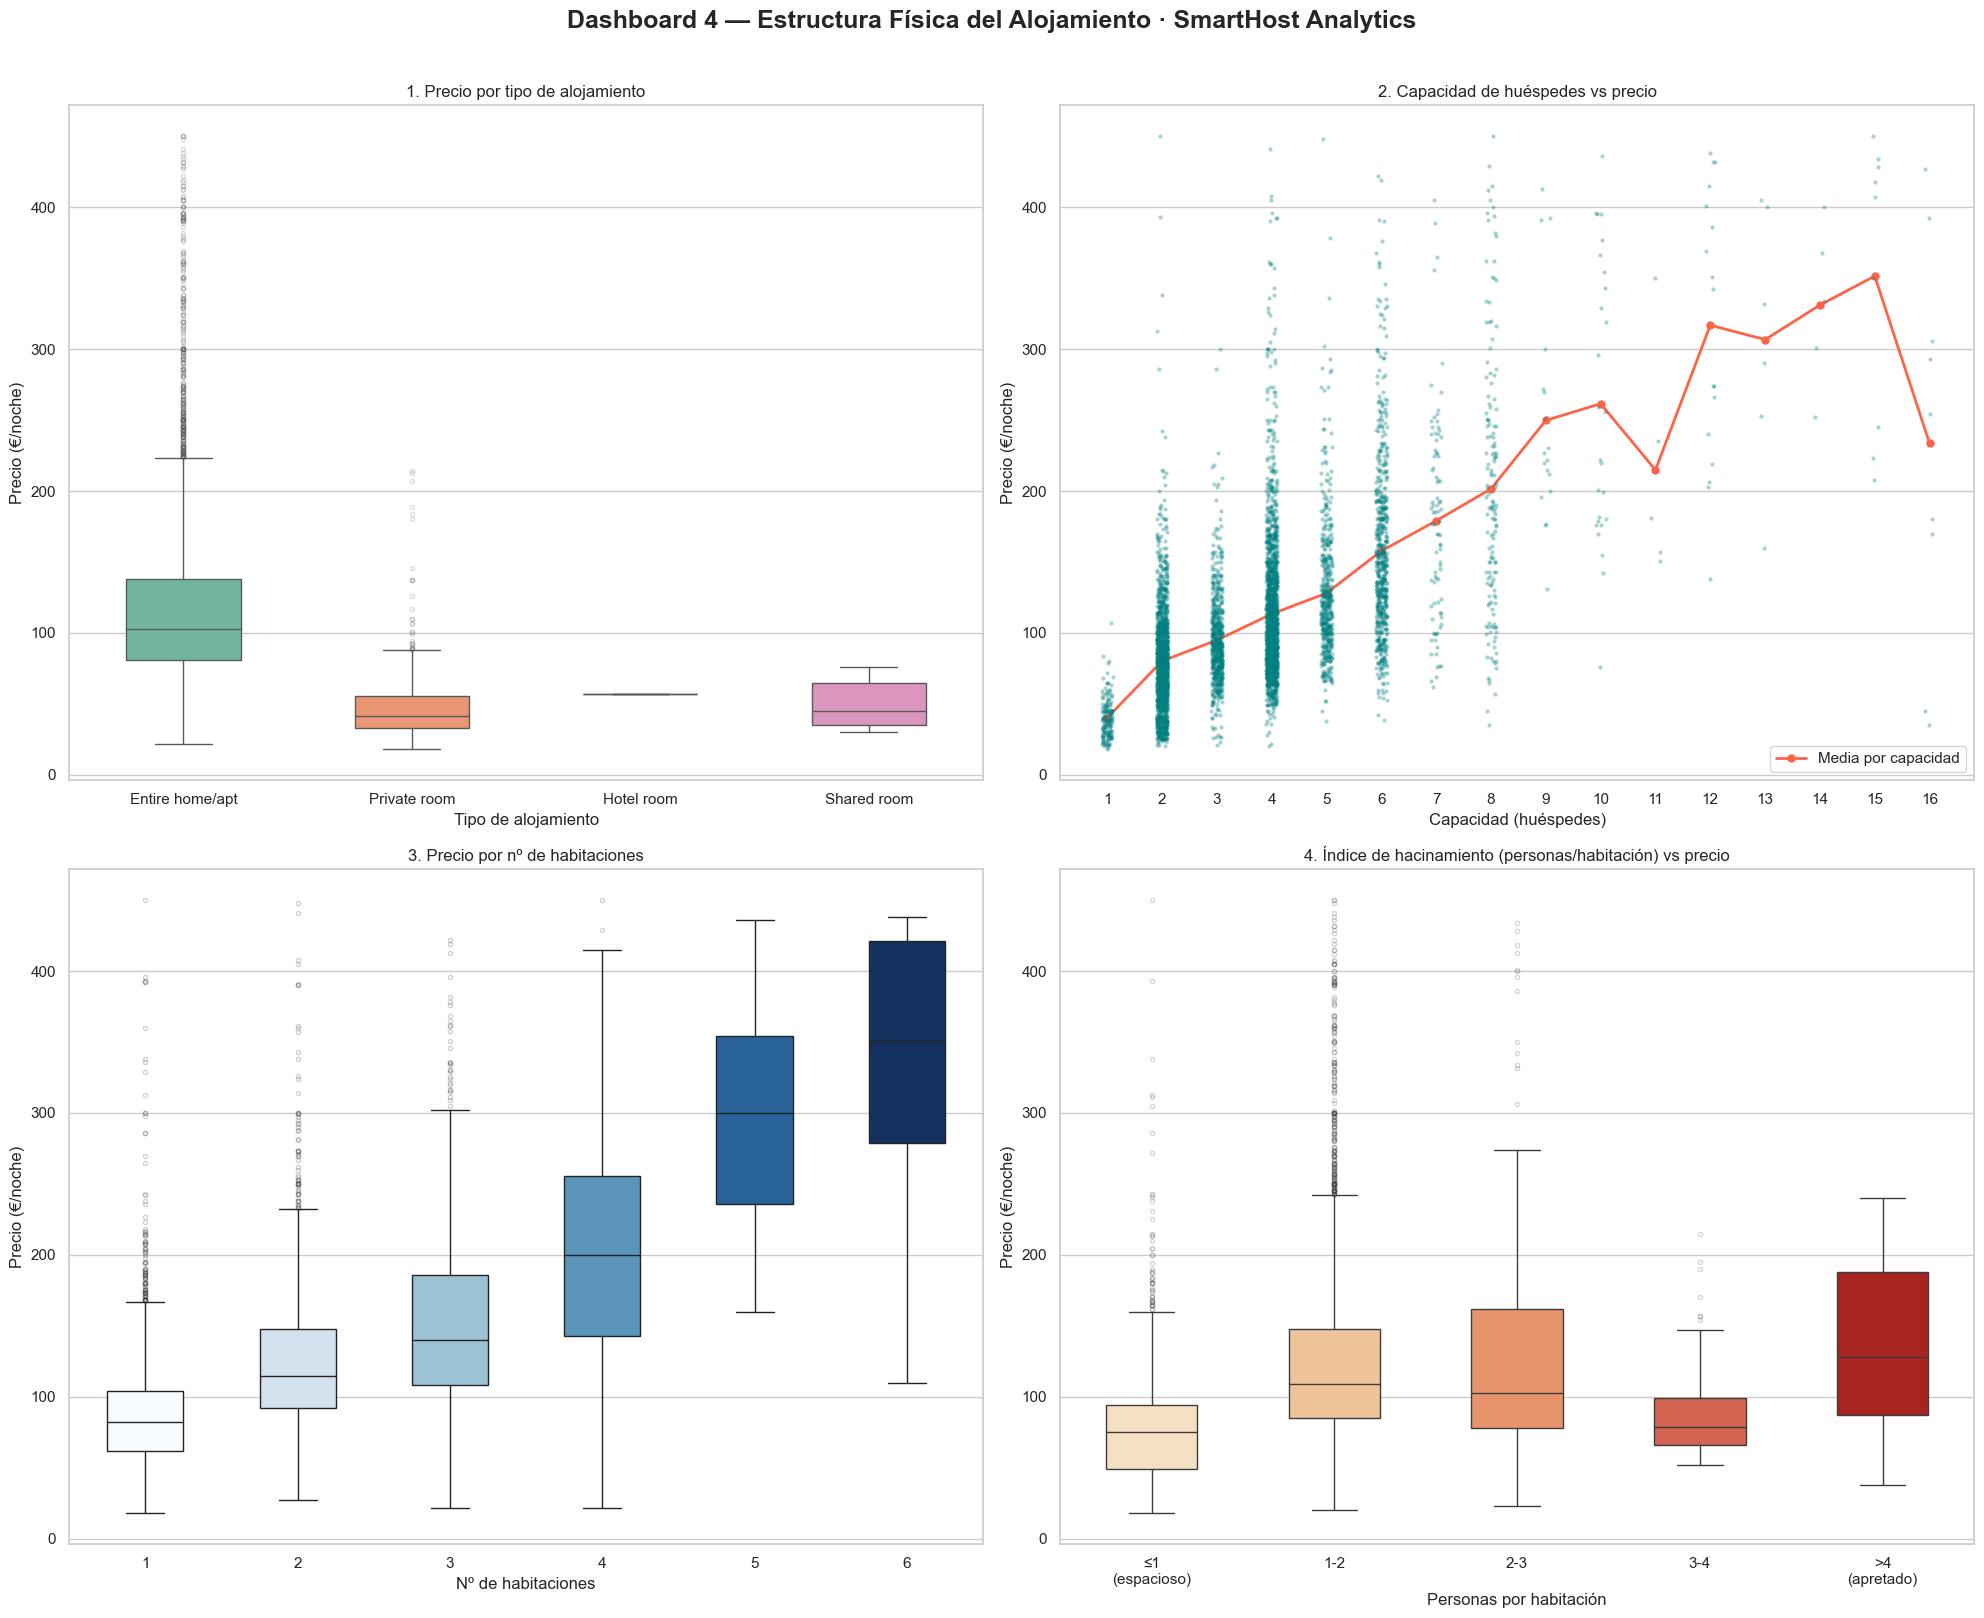

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# ── Preparación de datos ──────────────────────────────────────────────────────
df_vis = df[df['price'].between(10, 450)].copy()

# Índice de hacinamiento: personas por habitación (cap a 6 para visualización)
df_vis['personas_por_hab_clip'] = df_vis['personas_por_habitacion'].clip(upper=6)

# ── Lienzo ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Dashboard 4 — Estructura Física del Alojamiento · SmartHost Analytics',
            fontsize=18, fontweight='bold', y=1.01)

# =========================================================
# GRÁFICA 1: Boxplot precio por room_type
# =========================================================
sns.boxplot(data=df_vis, x='room_type', y='price',
            hue='room_type', palette='Set2', width=0.5,
            flierprops=dict(marker='.', alpha=0.2), legend=False, ax=axes[0, 0])
axes[0, 0].set_title('1. Precio por tipo de alojamiento')
axes[0, 0].set_xlabel('Tipo de alojamiento')
axes[0, 0].set_ylabel('Precio (€/noche)')

# =========================================================
# GRÁFICA 2: Stripplot capacidad de huéspedes vs precio
# =========================================================
sns.stripplot(data=df_vis, x='accommodates', y='price',
                alpha=0.35, jitter=True, color='teal', size=3, ax=axes[0, 1])

# Línea de media por capacidad
media_cap = df_vis.groupby('accommodates')['price'].mean()
axes[0, 1].plot(range(len(media_cap)), media_cap.values,
                color='tomato', linewidth=2, marker='o', markersize=5,
                label='Media por capacidad')
axes[0, 1].set_title('2. Capacidad de huéspedes vs precio')
axes[0, 1].set_xlabel('Capacidad (huéspedes)')
axes[0, 1].set_ylabel('Precio (€/noche)')
axes[0, 1].legend()

# =========================================================
# GRÁFICA 3: Boxplot precio por nº de habitaciones
# =========================================================
df_bed = df_vis[df_vis['bedrooms'].between(1, 6)].copy()
df_bed['bedrooms'] = df_bed['bedrooms'].astype(int)
sns.boxplot(data=df_bed, x='bedrooms', y='price',
            hue='bedrooms', palette='Blues', width=0.5,
            flierprops=dict(marker='.', alpha=0.2), legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. Precio por nº de habitaciones')
axes[1, 0].set_xlabel('Nº de habitaciones')
axes[1, 0].set_ylabel('Precio (€/noche)')

# =========================================================
# GRÁFICA 4: Índice de hacinamiento vs precio (discretizado)
# =========================================================

# Discretizar personas_por_habitacion en 5 rangos interpretables
df_vis['idx_hacinamiento'] = pd.cut(
    df_vis['personas_por_habitacion'],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=['≤1\n(espacioso)', '1-2', '2-3', '3-4', '>4\n(apretado)']
)

sns.boxplot(data=df_vis.dropna(subset=['idx_hacinamiento']),
            x='idx_hacinamiento', y='price',
            hue='idx_hacinamiento',
            palette='OrRd', width=0.5,
            flierprops=dict(marker='.', alpha=0.2),
            legend=False, ax=axes[1, 1])

axes[1, 1].set_title('4. Índice de hacinamiento (personas/habitación) vs precio')
axes[1, 1].set_xlabel('Personas por habitación')
axes[1, 1].set_ylabel('Precio (€/noche)')

plt.tight_layout()
plt.savefig('../data/dashboard3_estructura.png', dpi=300)
plt.show()

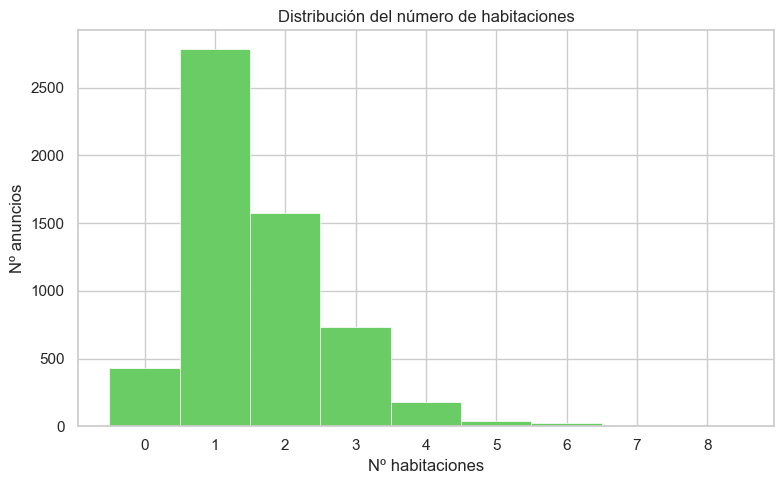

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

beds_clip = df["bedrooms"].dropna()
beds_clip = beds_clip[beds_clip <= 8]
ax.hist(beds_clip, bins=range(0, 10), edgecolor="white", linewidth=0.5,
        align="left", color=sns.color_palette("muted")[2])

ax.set_title("Distribución del número de habitaciones")
ax.set_xlabel("Nº habitaciones")
ax.set_ylabel("Nº anuncios")
ax.set_xticks(range(0, 9))
plt.tight_layout()
plt.show()

### 1. Tipo de alojamiento: la brecha entre piso entero y habitación privada

Como era esperable, **`Entire home/apt` lidera ampliamente en precio** tanto en mediana (~110 €) como en rango intercuartílico. Las habitaciones privadas (`Private room`) muestran una mediana de ~45 €, y las compartidas (`Shared room`) se sitúan en un rango similar pero con mayor concentración.

Lo más relevante para el modelo no es solo la diferencia de medianas, sino la **amplitud del boxplot de piso entero**: el rango intercuartílico es enorme (de ~75 € a ~140 €) con una larga cola superior de outliers que llegan a 400 €. Esto confirma que `room_type` **por sí solo no es suficiente** para predecir el precio — necesita combinarse con otras variables como ubicación, capacidad y servicios.

> **Implicación para el modelo:** `room_type` debe codificarse como variable categórica (one-hot o embedding) y se espera que sea uno de los features con mayor peso en la red. Sin embargo, su interacción con `neighbourhood_cleansed` y `accommodates` será clave para capturar la variabilidad interna de cada categoría.

---

### 2. Capacidad de huéspedes: crecimiento lineal con ruptura a partir de 8

El stripplot muestra una **tendencia creciente clara y aproximadamente lineal** entre 1 y 8 huéspedes: a más capacidad, mayor precio medio por noche. La línea de tendencia confirma esta subida progresiva.

A partir de **8-9 huéspedes**, el comportamiento se vuelve irregular: los precios medios oscilan y la muestra se reduce drásticamente (pocos anuncios para esas capacidades). Esto genera ruido en la tendencia para valores altos.

> **Hipótesis:** Los alojamientos de gran capacidad (10+ huéspedes) son casos atípicos — principalmente villas o chalets de lujo con precios muy variables dependiendo de sus características. El modelo podría tener dificultades con estos extremos si no hay suficiente muestra.

---

### 3. Número de habitaciones: la relación más limpia del dashboard

El boxplot de `bedrooms` es el que muestra la **progresión más ordenada y consistente** de todo el dashboard: cada habitación adicional eleva la mediana de precio de forma clara y sin excepciones, desde ~80 € (1 hab.) hasta ~345 € (6 hab.).

> **Implicación para el modelo:** `bedrooms` es una feature **numérica con relación monótona** con el precio — exactamente el tipo de variable que las redes neuronales aprenden bien. Junto con `accommodates`, forma el núcleo de la "dimensión física" del alojamiento.

---

### 4. Índice de hacinamiento: el resultado contraintuitivo

Este es el gráfico más sorprendente. La hipótesis inicial sería esperar que **a mayor hacinamiento (más personas por habitación), menor precio** — ya que valores altos corresponden a habitaciones compartidas baratas. Sin embargo, el resultado muestra medianas bastante parejas entre los rangos 1-2, 2-3 y 3-4, e incluso el rango **>4 tiene una mediana similar o ligeramente superior**.

Hay varias explicaciones posibles para este comportamiento:

> **Hipótesis 1 — Confusión con `room_type`:** Los rangos altos de hacinamiento no son exclusivamente habitaciones compartidas. Un piso entero de 1 habitación con 4 huéspedes (índice = 4) puede cobrar 120 €/noche perfectamente. El hacinamiento no distingue el tipo de propiedad, y eso diluye la señal esperada.

> **Hipótesis 2 — El precio es por noche, no por persona:** Un apartamento de 2 habitaciones con 6 personas (índice = 3) puede cobrar 150 €/noche — un precio "alto" en términos absolutos aunque barato por persona. Al visualizar el precio total por noche, los alojamientos más apretados no parecen baratos si tienen buena ubicación o servicios.

> **Hipótesis 3 — La variable `personas_por_habitacion` necesita interacciones:** Su poder predictivo real puede emerger cuando se combina con `room_type` o `accommodates`, no de forma aislada. En aislamiento, la señal queda enmascarada.

> **Conclusión para el modelo:** `personas_por_habitacion` no muestra una relación directa y limpia con el precio cuando se visualiza en solitario. Puede seguir siendo útil como feature por sus interacciones implícitas dentro de la red neuronal, pero **no debe esperarse que sea un predictor fuerte por sí mismo**..

### Dashboard 5 - Amenities y calidad

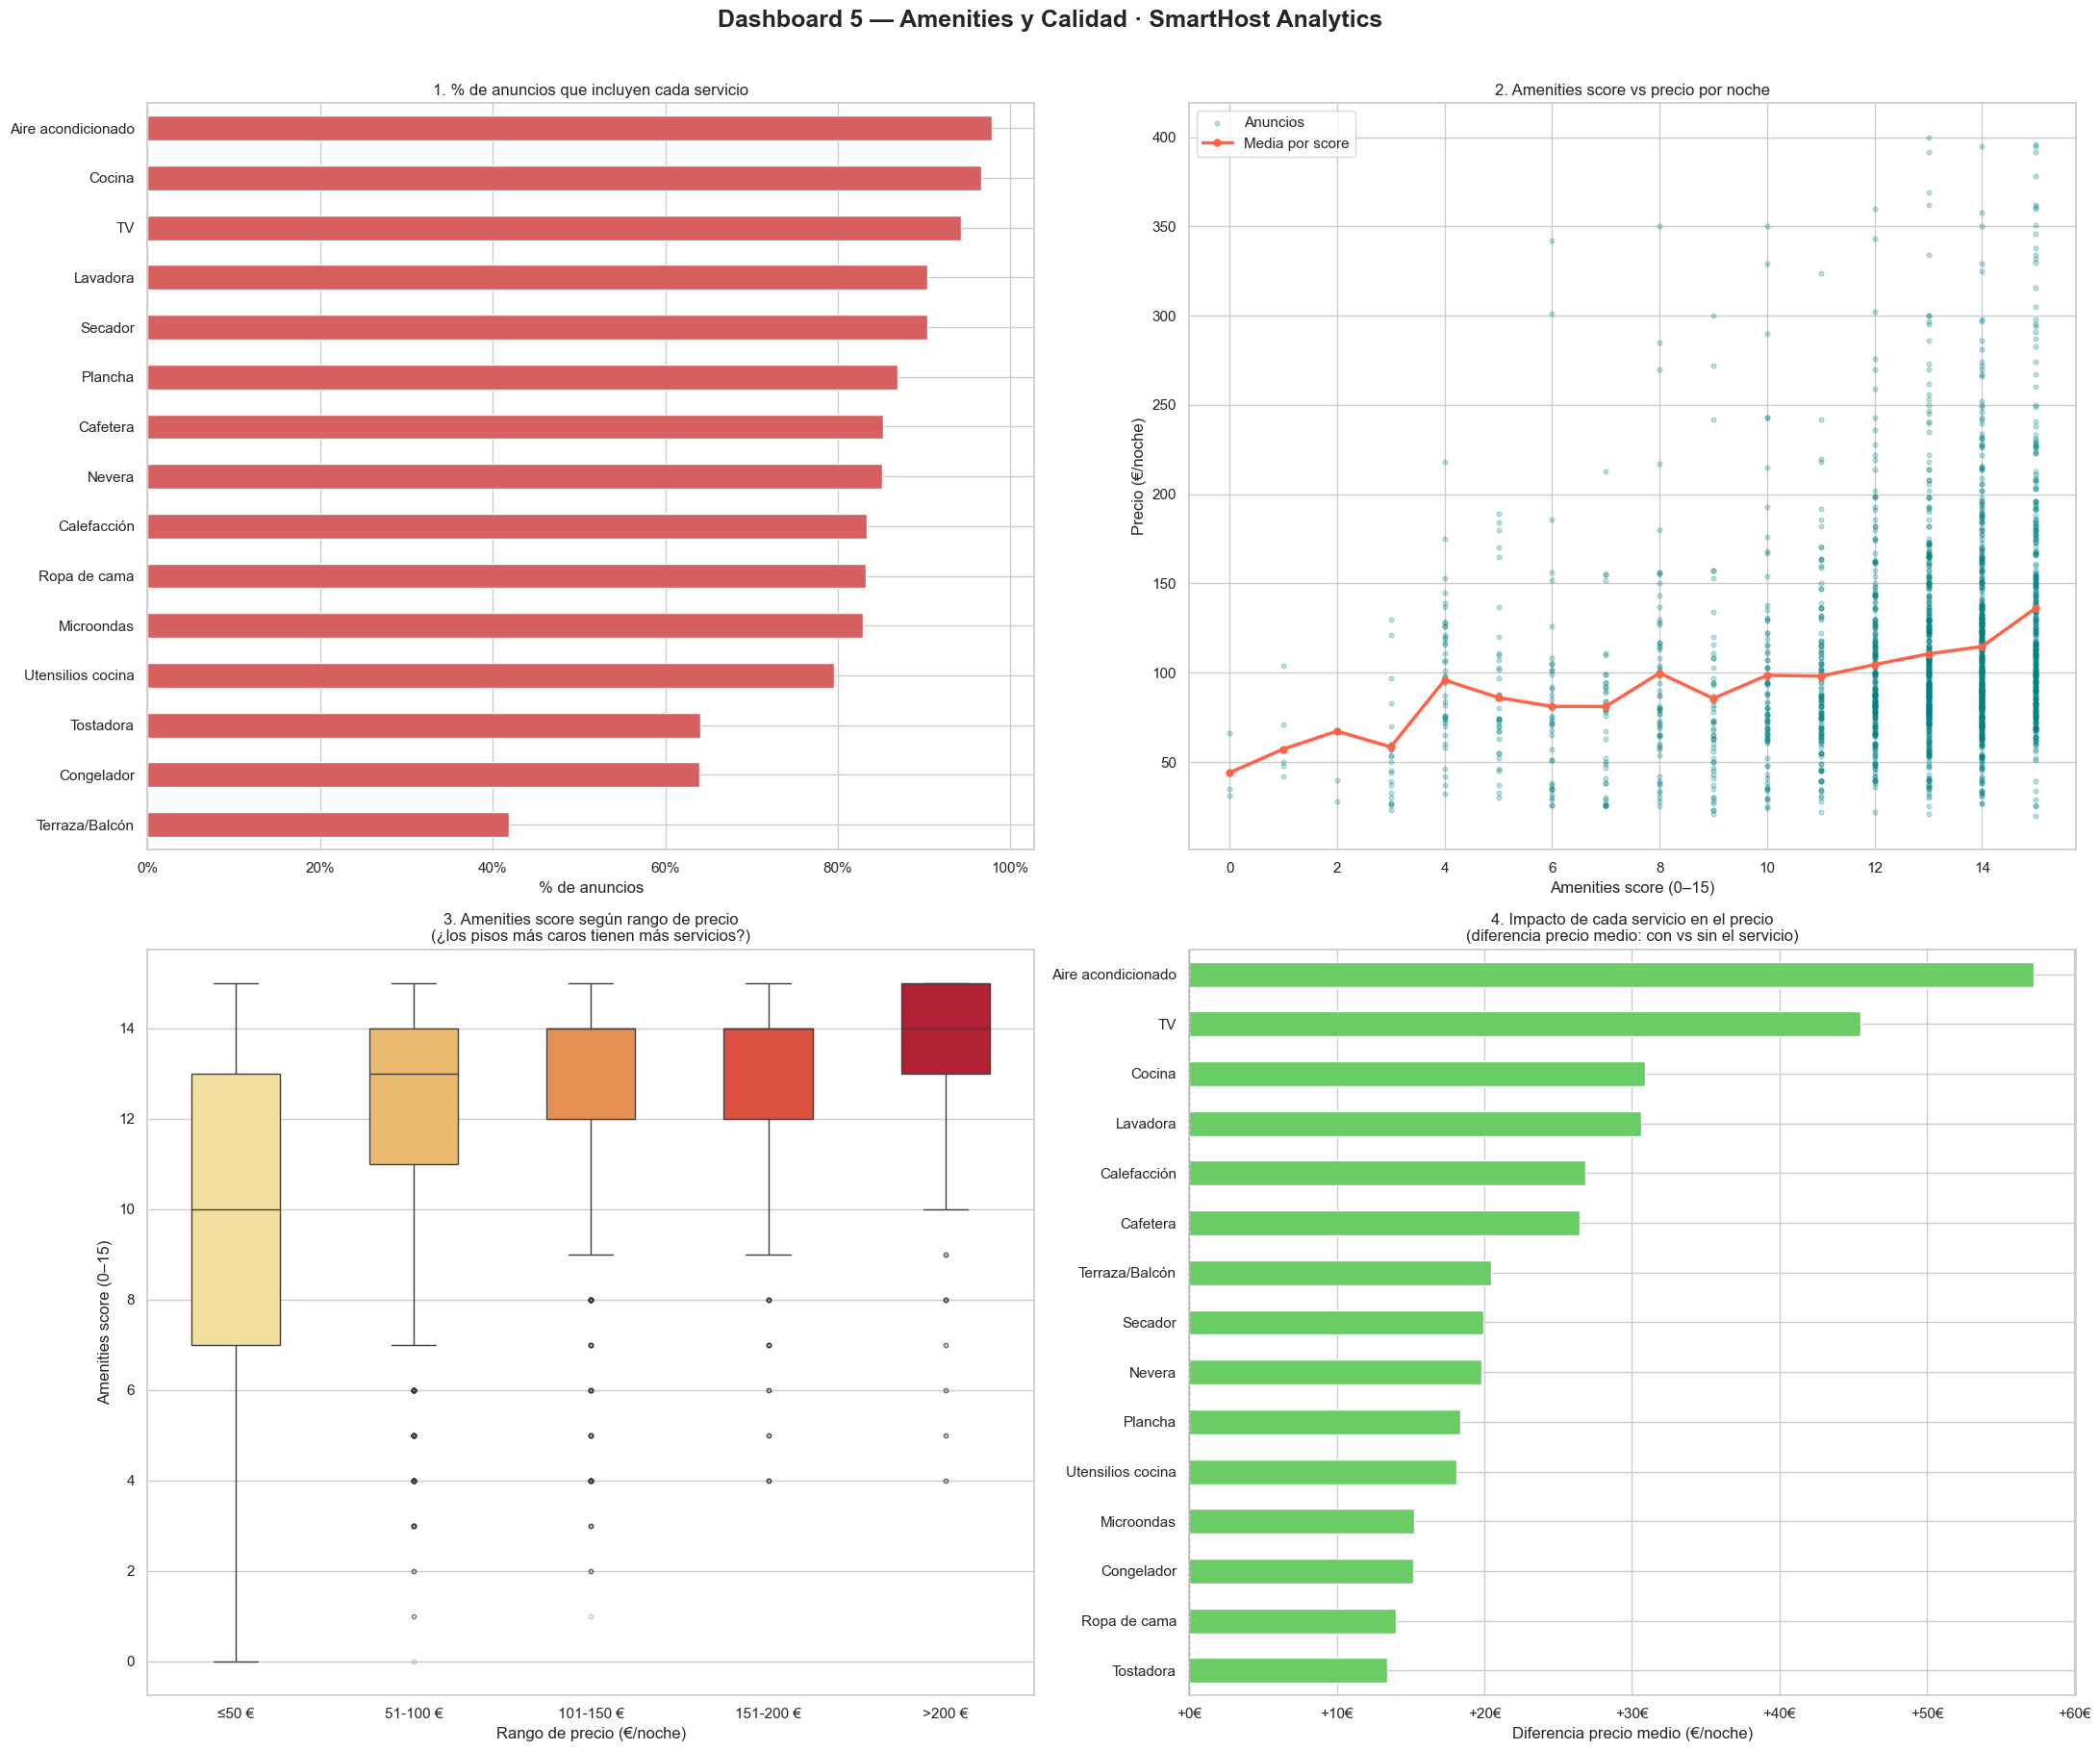

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# ── Preparación de datos ──────────────────────────────────────────────────────
df_vis  = df[df['price'].between(10, 400)].copy()
sample  = df_vis.sample(min(2000, len(df_vis)), random_state=42)

amenity_cols = [
    "has_kitchen", "has_hair_dryer", "has_iron", "has_bed_linens",
    "has_microwave", "has_refrigerator", "has_cooking_basics", "has_tv",
    "has_air_conditioning", "has_washer", "has_toaster", "has_heating",
    "has_freezer", "has_coffee_maker", "has_balcony_or_terrace"
]
amenity_labels = {
    "has_kitchen": "Cocina", "has_hair_dryer": "Secador", "has_iron": "Plancha",
    "has_bed_linens": "Ropa de cama", "has_microwave": "Microondas",
    "has_refrigerator": "Nevera", "has_cooking_basics": "Utensilios cocina",
    "has_tv": "TV", "has_air_conditioning": "Aire acondicionado",
    "has_washer": "Lavadora", "has_toaster": "Tostadora",
    "has_heating": "Calefacción", "has_freezer": "Congelador",
    "has_coffee_maker": "Cafetera", "has_balcony_or_terrace": "Terraza/Balcón"
}
amenity_pct = (df[amenity_cols].mean() * 100).rename(amenity_labels).sort_values(ascending=True)

# Rangos de precio para gráfico 3
df_vis['precio_rango'] = pd.cut(
    df_vis['price'],
    bins=[0, 50, 100, 150, 200, 400],
    labels=['≤50 €', '51-100 €', '101-150 €', '151-200 €', '>200 €']
)

# Sub-scores de reviews para gráfico 4
review_cols = {
    'review_scores_cleanliness': 'Limpieza',
    'review_scores_checkin':     'Check-in',
    'review_scores_communication':'Comunicación',
    'review_scores_location':    'Ubicación',
    'review_scores_value':       'Valor/precio'
}
df_rev = df_vis.dropna(subset=list(review_cols.keys()) + ['host_is_superhost']).copy()
df_rev['Superhost'] = df_rev['host_is_superhost'].map({1: 'Superhost', 0: 'No Superhost'})
rev_media = (df_rev.groupby('Superhost')[list(review_cols.keys())]
            .mean()
            .rename(columns=review_cols))

# ── Lienzo 2x2 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.suptitle('Dashboard 5 — Amenities y Calidad · SmartHost Analytics',
            fontsize=18, fontweight='bold', y=1.01)

# =========================================================
# GRÁFICA 1: % anuncios con cada servicio
# =========================================================
amenity_pct.plot(kind='barh', ax=axes[0, 0],
                color=sns.color_palette('muted')[3], edgecolor='white')
axes[0, 0].set_title('1. % de anuncios que incluyen cada servicio')
axes[0, 0].set_xlabel('% de anuncios')
axes[0, 0].set_ylabel('')
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# =========================================================
# GRÁFICA 2: Scatter amenities_score vs precio
# =========================================================
axes[0, 1].scatter(sample['amenities_score'], sample['price'],
                    alpha=0.25, s=12, color='teal', label='Anuncios')
trend_a = (df_vis.groupby('amenities_score')['price']
            .mean().reset_index().sort_values('amenities_score'))
axes[0, 1].plot(trend_a['amenities_score'], trend_a['price'],
                color='tomato', linewidth=2.5, marker='o', markersize=5,
                label='Media por score')
axes[0, 1].set_title('2. Amenities score vs precio por noche')
axes[0, 1].set_xlabel('Amenities score (0–15)')
axes[0, 1].set_ylabel('Precio (€/noche)')
axes[0, 1].legend()

# =========================================================
# GRÁFICA 3: Boxplot amenities_score por rango de precio
# =========================================================
sns.boxplot(data=df_vis.dropna(subset=['precio_rango']),
            x='precio_rango', y='amenities_score',
            hue='precio_rango', palette='YlOrRd', width=0.5,
            flierprops=dict(marker='.', alpha=0.3),
            legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. Amenities score según rango de precio\n(¿los pisos más caros tienen más servicios?)')
axes[1, 0].set_xlabel('Rango de precio (€/noche)')
axes[1, 0].set_ylabel('Amenities score (0–15)')

# =========================================================
# GRÁFICA 4: Diferencia de precio medio por amenity (tienen vs no tienen)
# =========================================================
df_am = df[df['price'].between(10, 400)].copy()

diffs = {}
for col in amenity_cols:
    media_con    = df_am[df_am[col] == 1]['price'].mean()
    media_sin    = df_am[df_am[col] == 0]['price'].mean()
    diffs[amenity_labels[col]] = media_con - media_sin

diffs_series = pd.Series(diffs).sort_values(ascending=True)
colors_diff  = ['tomato' if v < 0 else sns.color_palette('muted')[2] for v in diffs_series]

diffs_series.plot(kind='barh', ax=axes[1, 1], color=colors_diff, edgecolor='white')
axes[1, 1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 1].set_title('4. Impacto de cada servicio en el precio\n(diferencia precio medio: con vs sin el servicio)')
axes[1, 1].set_xlabel('Diferencia precio medio (€/noche)')
axes[1, 1].set_ylabel('')
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}€'))

plt.tight_layout()
plt.savefig('../data/dashboard4_amenities.png', dpi=300)
plt.show()

### 1. Frecuencia de servicios: lo básico domina

El gráfico 1 muestra que el top de servicios más extendidos — **aire acondicionado (~97%), cocina, TV, lavadora, secador y plancha** — son precisamente las comodidades que un viajero da por sentadas en un apartamento turístico moderno. Su alta prevalencia no es casual: en el mercado de alquiler vacacional, estos servicios han dejado de ser diferenciadores para convertirse en **requisitos mínimos de entrada**. Un anuncio sin cocina o sin lavadora se percibe como incompleto y compite en precio, no en valor.

En el extremo opuesto, **terraza/balcón (~40%), congelador y tostadora** son los menos frecuentes. La terraza es el único de los tres con peso aspiracional real — los otros dos son simplemente complementos que pocos anfitriones consideran relevantes para listar.

> **Implicación para el modelo:** Las amenities más frecuentes tienen menor poder discriminatorio individual — si el 97% las tiene, su presencia apenas separa unos anuncios de otros. Su ausencia, en cambio, sí penaliza. Esto justifica el diseño del `amenities_score` como suma ponderada: acumula señal de múltiples servicios en lugar de depender de uno solo.

---

### 2 y 3. A más servicios, mayor precio: una relación confirmada desde ambos ángulos

Los gráficos 2 y 3 cuentan la misma historia desde perspectivas complementarias y se refuerzan mutuamente. El scatter (gráfico 2) muestra que la **línea de tendencia crece de forma clara** a medida que aumenta el `amenities_score`, con el suelo de precios y los máximos elevándose en paralelo. El boxplot por rangos de precio (gráfico 3) lo confirma en sentido inverso: los apartamentos más baratos (≤50 €) tienen una mediana de score de ~10 y una dispersión enorme, mientras que los de >200 €/noche se agrupan en scores de 13-15 con poca variabilidad.

El **salto más notable** se produce entre el rango ≤50 € y el resto: los alojamientos más económicos son los únicos con scores bajos frecuentes, lo que sugiere que tener pocos servicios condena el precio al segmento más bajo, pero a partir de un cierto umbral de servicios (~10-11), los factores diferenciadores pasan a ser otros (ubicación, tamaño, calidad del anfitrión).

> **Hipótesis:** El `amenities_score` actúa como **proxy de calidad general del alojamiento**. No es que la tostadora suba el precio, sino que los anfitriones que cuidan los detalles y equipan bien su piso tienden también a tener mejor ubicación, fotografías más cuidadas y mayor experiencia — todo ello correlaciona con precios más altos.

---

### 4. Impacto económico por servicio: el aire acondicionado lidera con >50 €

El gráfico 4 es el más accionable del dashboard. La diferencia de precio medio entre tener y no tener **aire acondicionado supera los 55 €/noche** — una cifra llamativa que refleja la realidad climática de Málaga, donde las temperaturas estivales hacen del climatizador un elemento casi imprescindible. Su ausencia es probablemente el mayor desincentivo para el viajero de verano.

**TV, cocina y lavadora** aparecen en segundo lugar (~30-45 €), confirmando que la ausencia de servicios básicos penaliza el precio más de lo que su presencia lo sube. El dato más interesante para el modelo es que la **terraza/balcón** (~22 €) aparece en la zona media pese a ser un servicio poco frecuente — esto indica que cuando está presente, sí tiene un impacto real en el precio, siendo el único "extra de calidad" que compite en impacto con los básicos.

En el extremo inferior, **tostadora, ropa de cama y congelador** tienen el menor impacto (~10-12 €), lo que sugiere que son servicios indiferentes para la mayoría de viajeros a la hora de elegir y pagar.

> **Conclusión para el modelo:** El gráfico sugiere que no todas las amenities del score contribuyen igual. En versiones futuras del modelo podría explorarse un **score ponderado** que asigne mayor peso al aire acondicionado, TV y terraza, y menor a tostadora o congelador. No obstante, para la red neuronal tabular, esta ponderación puede emerger de forma implícita a través del entrenamiento si las variables individuales se incluyen como features binarias adicionales al score agregado.

### Dashboard 6 - Superhost

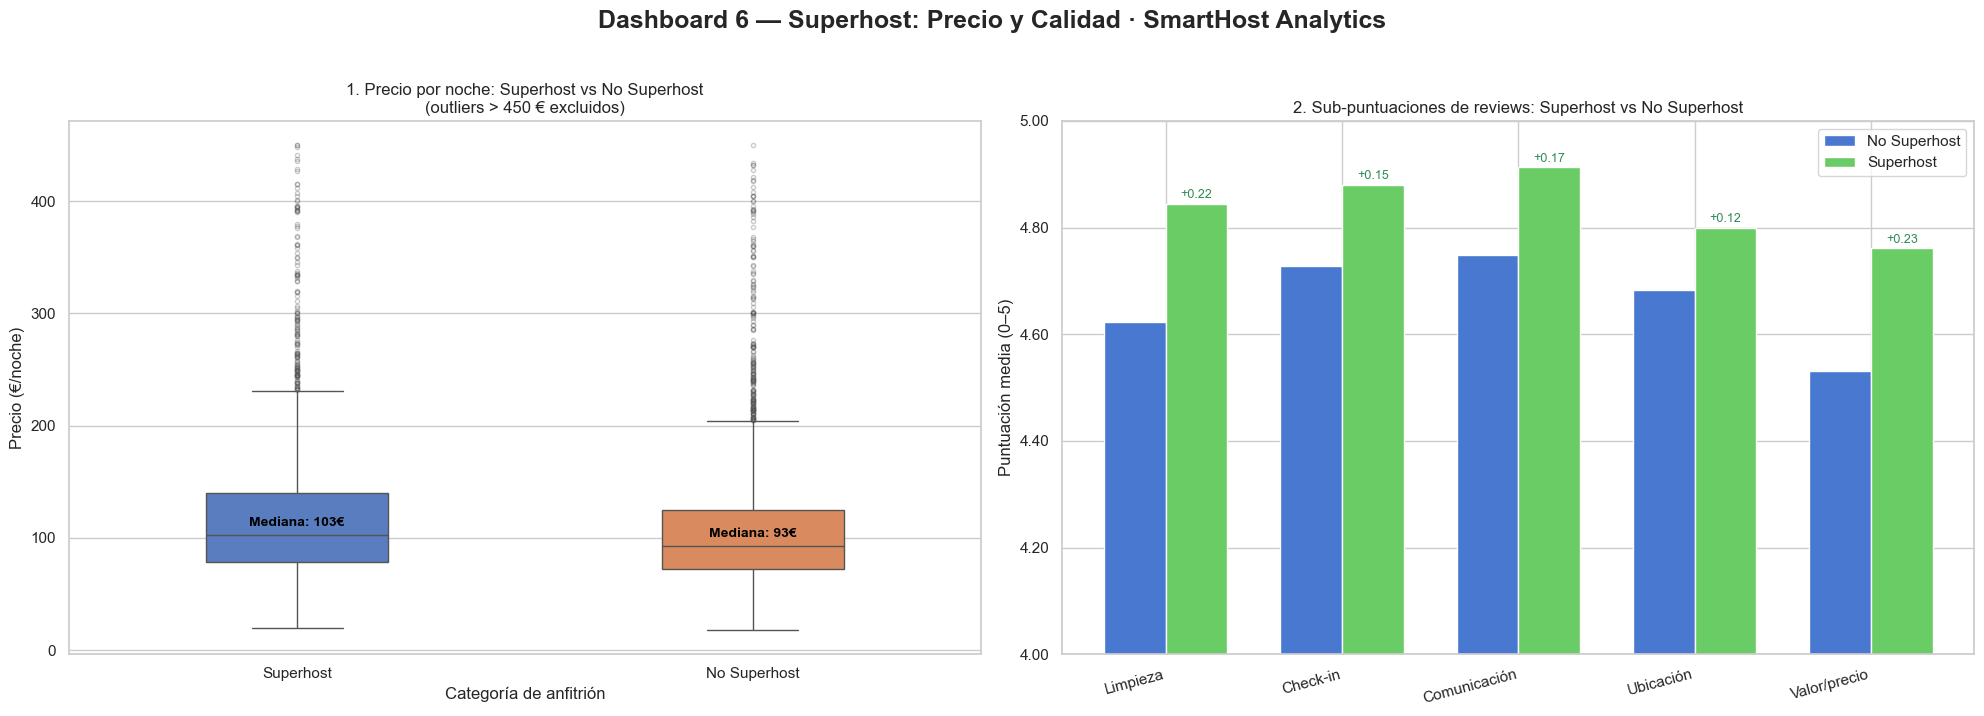

               count   mean   std   min   25%    50%    75%    max
sh_label                                                          
No Superhost  3296.0  106.9  58.9  18.0  72.0   93.0  125.0  450.0
Superhost     2267.0  119.0  66.3  20.0  79.0  103.0  140.0  450.0


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# ── Preparación de datos ──────────────────────────────────────────────────────
df_sh = df[df['price'].between(10, 450)].copy()
df_sh['sh_label'] = df_sh['host_is_superhost'].map({1.0: 'Superhost', 0.0: 'No Superhost'})
df_sh = df_sh.dropna(subset=['sh_label'])

review_cols = {
    'review_scores_cleanliness':  'Limpieza',
    'review_scores_checkin':      'Check-in',
    'review_scores_communication':'Comunicación',
    'review_scores_location':     'Ubicación',
    'review_scores_value':        'Valor/precio'
}
df_rev = df_sh.dropna(subset=list(review_cols.keys())).copy()
rev_media = (df_rev.groupby('sh_label')[list(review_cols.keys())]
            .mean().rename(columns=review_cols))

# ── Lienzo 1x2 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Dashboard 6 — Superhost: Precio y Calidad · SmartHost Analytics',
            fontsize=18, fontweight='bold', y=1.02)

# =========================================================
# GRÁFICA 1: Boxplot precio Superhost vs No Superhost
# =========================================================
# Orden explícito que controla tanto el boxplot como las anotaciones
orden = ['Superhost', 'No Superhost']

sns.boxplot(data=df_sh, x='sh_label', y='price',
            order=orden,                          # ← fuerza el orden visual
            hue='sh_label', hue_order=orden,
            palette='muted', width=0.4,
            flierprops=dict(marker='.', alpha=0.3),
            legend=False, ax=axes[0])
axes[0].set_title('1. Precio por noche: Superhost vs No Superhost\n(outliers > 450 € excluidos)')
axes[0].set_xlabel('Categoría de anfitrión')
axes[0].set_ylabel('Precio (€/noche)')

# Anotar medianas usando el mismo orden que el eje X
for i, label in enumerate(orden):           # ← mismo orden que el boxplot
    med = df_sh[df_sh['sh_label'] == label]['price'].median()
    axes[0].text(i, med + 5, f'Mediana: {med:.0f}€',
                ha='center', va='bottom', fontsize=10,
                fontweight='bold', color='black')

# =========================================================
# GRÁFICA 2: Barras sub-scores reviews Superhost vs No Superhost
# =========================================================
x     = np.arange(len(review_cols))
width = 0.35
colors = [sns.color_palette('muted')[0], sns.color_palette('muted')[2]]

for i, (label, color) in enumerate(zip(rev_media.index, colors)):
    axes[1].bar(x + i * width, rev_media.loc[label],
                width, label=label, color=color, edgecolor='white')

axes[1].set_title('2. Sub-puntuaciones de reviews: Superhost vs No Superhost')
axes[1].set_xlabel('')
axes[1].set_ylabel('Puntuación media (0–5)')
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(list(review_cols.values()), rotation=15, ha='right')
axes[1].set_ylim(4.0, 5.0)
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

# Anotar diferencias encima de cada par de barras
for j, col in enumerate(rev_media.columns):
    val_sh  = rev_media.loc['Superhost', col]
    val_no  = rev_media.loc['No Superhost', col]
    diff    = val_sh - val_no
    axes[1].text(j + width, max(val_sh, val_no) + 0.005,
                f'+{diff:.2f}' if diff >= 0 else f'{diff:.2f}',
                ha='center', va='bottom', fontsize=9,
                color='tomato' if diff < 0 else 'seagreen')

plt.tight_layout()
plt.savefig('../data/dashboard5_superhost.png', dpi=300)
plt.show()

# Estadísticas comparativas
print(df_sh.groupby('sh_label')['price'].describe().round(1))

### 1. Precio: los Superhosts cobran ligeramente más

La diferencia de medianas es **moderada pero consistente**: Superhost (103 €) vs No Superhost (93 €), una brecha de 10 €/noche. Los rangos intercuartílicos son similares, y ambos grupos comparten una larga cola de outliers en precios altos, lo que indica que la categoría Superhost está presente en todos los segmentos de precio — no es exclusiva del lujo.

Lo más relevante no es la diferencia absoluta de precio, sino que los Superhosts **consiguen cobrar más manteniendo mejores valoraciones**, lo cual implica que su ventaja competitiva no está en abaratar, sino en justificar un precio algo superior con mejor calidad percibida.

> **Hipótesis:** El badge de Superhost actúa como señal de confianza que reduce la fricción en la decisión de reserva. En un mercado donde el viajero no puede inspeccionar físicamente el alojamiento antes de reservar, la reputación del anfitrión funciona como garantía implícita — y eso tiene un precio.

---

### 2. Reviews: los Superhosts puntúan mejor en todas las dimensiones

El gráfico de sub-puntuaciones no deja lugar a dudas: los Superhosts superan a los No Superhosts en **todos y cada uno de los cinco indicadores** medidos, con las mayores brechas en **Valor/precio (+0.23)** y **Limpieza (+0.22)**. Esto es especialmente significativo en "Valor/precio": pese a cobrar más, los huéspedes perciben que reciben más a cambio — el indicador más difícil de mejorar para cualquier anfitrión.

La brecha más pequeña corresponde a **Ubicación (+0.12)**, lo cual es lógico: la ubicación del piso no depende del anfitrión y es independiente de su categoría. Que aun así los Superhosts puntúen algo mejor en ubicación podría indicar que, en promedio, tienen sus propiedades en zonas algo mejor valoradas.

> **Implicación para el modelo:** `host_is_superhost` es una feature binaria con señal real y medible sobre la calidad percibida. Sin embargo, parte de su impacto ya está capturado indirectamente por variables como `review_scores_rating` o `review_scores_value`. Será interesante evaluar, tras el entrenamiento, si el Superhost aporta información **residual** una vez que las puntuaciones de reviews están incluidas, o si su importancia queda absorbida por ellas.

---

### Correlaciones definitivas

In [11]:
#(librería para la descarga de la figura en PNG)
#pip install --upgrade kaleido 

#Correlacion de las columnas con el precio por noche
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go


df = pd.read_csv('../data/listingV5.csv')

correlacion = df.corr(numeric_only=True)['price'].drop('price').sort_values()

colors = ['#ef4444' if v < 0 else '#3b82f6' for v in correlacion.values]

fig = go.Figure(go.Bar(
    x=correlacion.values,
    y=correlacion.index,
    orientation='h',
    marker_color=colors,
    text=[f"{v:.3f}" for v in correlacion.values],
    textposition='outside'
))

fig.update_layout(title="Correlación variables numéricas con Price", height=1400)
fig.update_xaxes(title_text="Correlación r")
fig.update_yaxes(title_text="Variable")
fig.add_vline(x=0.1, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=-0.1, line_dash="dash", line_color="gray", opacity=0.5)
fig.show()

# Guardar como imagen
fig.write_image('../data/correlacion_precio.png', width=1400, height=1400, scale=2)
print("Imagen guardada en ../data/correlacion_precio.png")

Imagen guardada en ../data/correlacion_precio.png


### Correlaciones positivas fuertes (r > 0.45): tamaño del alojamiento

Las variables con mayor correlación son todas de **dimensión física**: `accommodates` (0.524), `bathrooms` (0.505), `bedrooms` (0.491) y `beds` (0.473). A más grande el piso, mayor precio — relación clara y esperada. `estimated_revenue_l365d` (0.496) aparece aquí porque los pisos más caros generan más ingresos anuales. `price_per_person` (0.659) tiene correlación artificialmente alta al ser una variable derivada del propio precio (eliminar en el entrenamiento del modelo para evitar data leakage).

### Correlaciones positivas moderadas (0.10 < r < 0.45): calidad y servicios

`amenities_score` (0.158), `has_balcony_or_terrace` (0.140), `review_scores_location` (0.140) y `review_scores_rating` (0.137) tienen peso moderado. Confirman los hallazgos de los dashboards anteriores: la calidad y los servicios influyen, pero menos que el tamaño físico.

### Correlaciones negativas: el efecto ocupación

`reviews_per_month` (-0.128), `estimated_occupancy_l365d` (-0.127) y `number_of_reviews` (-0.095) correlacionan negativamente. Los pisos baratos se reservan con más frecuencia y acumulan más reviews — **volumen y precio alto son estrategias opuestas** en este mercado.

### Variables con correlación débil (|r| < 0.10)

`distancia_playa_km`, `latitude` o `minimum_nights` muestran r ≈ 0. No significa que sean irrelevantes — su relación con el precio es **no lineal**, pero una red neuronal sí puede aprender.

> **Conclusión:** El precio está dominado linealmente por el tamaño físico. El resto de variables relevantes (barrio, tipo de alojamiento, distancias) tienen relaciones no lineales que justifican el uso de una red neuronal frente a una regresión lineal clásica.

In [12]:
from scipy import stats
import pandas as pd

cols_categoricas = df.select_dtypes(include='object').columns.tolist()

resultados_anova = []

for col in cols_categoricas:
    grupos = [df[df[col] == cat]['price'].dropna()
            for cat in df[col].dropna().unique()
            if len(df[df[col] == cat]['price'].dropna()) > 1]  # evitar grupos vacíos
    
    if len(grupos) > 1:  # ANOVA necesita al menos 2 grupos
        f_stat, p_valor = stats.f_oneway(*grupos)
        resultados_anova.append({'columna': col, 'p_valor': round(p_valor, 6)})
    else:
        resultados_anova.append({'columna': col, 'p_valor': None})

resultados_anova_df = pd.DataFrame(resultados_anova).sort_values('p_valor')
print(resultados_anova_df.to_string())



                  columna  p_valor
1  neighbourhood_cleansed  0.00000
2           property_type  0.00000
3               room_type  0.00000
0      host_response_time  0.56752
